# Fig 4 — POU2F3+ tuft-like cancer population & relapse

Reproduces **Fig4** by inlining the actual generating code from the source notebooks/scripts. Set the paths in the config cell, then run top-to-bottom. Cost tags: 🟢 light · 🟡 moderate · 🔴 heavy.

> Excluded (non-code): Fig 4c Xenium H&E/POU2F3/ASCL2 micrographs. Fig 4b (right, label-transfer UMAP) and Fig 4d (signature UMAP) are produced by the label-transfer / Moorman-atlas code (cells 108/102/205/235) but are not saved as standalone PNGs matching the published crops, so they are not embedded below.

## Configuration — edit the paths, then run

In [ ]:
import os, sys, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")
try:
    import scanpy as sc
    import anndata as ad
except Exception as e:
    print("[note] scanpy/anndata not available:", e)

# ── EDIT THESE PATHS to match your environment ──
REPO_ROOT     = Path("/path/to/spatnic")          # this repository
BACKUP_ROOT   = Path("/path/to/backup")           # integrate_adata_filtered.h5ad, galaxy scores, Liver meta
DATA_ROOT     = Path("/path/to/data")             # GxD concat, lung annotated, c2l refs, spatnic_models, GxD_Xenium
BENCHMARK_DB  = Path("/path/to/benchmark_db")     # Xenium/VisiumHD/MERFISH/CosMx + adata_hvg_*
VISIUMHD_ROOT = Path("/path/to/VisiumHD")         # Visium HD ADC track
WEIGHTS_DIR   = Path.home() / ".spatnic" / "weights"

# ── Derived ──
NB     = REPO_ROOT / "notebooks"
COMP   = NB / "comparison_results"
VHD    = VISIUMHD_ROOT
MODELS = DATA_ROOT / "spatnic_models"
PAPER  = REPO_ROOT / "paper"
BASE_DIR  = VHD          # VisiumHD ADC notebook global
THRESHOLD = 0.9          # overridden to 0.5 by the Fig 5 shortcut setup cell
sys.path[:0] = [str(REPO_ROOT / "scripts"), str(NB)]
if NB.exists():
    os.chdir(NB)         # extracted cells were written for cwd = notebooks/

def _tbl(csv, n=None):
    p = Path(csv)
    if not p.exists():
        print("[missing]", p); return None
    df = pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)
    display(df.head(n) if n else df); return df

def _run(script, show=None, n=None):
    import subprocess
    cmd = f"python notebooks/{script}"
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=str(REPO_ROOT), capture_output=True, text=True)
    print((r.stdout or "")[-3000:])
    if r.returncode: print("STDERR:\n", (r.stderr or "")[-2000:])
    if show: _tbl(COMP / show, n)


### Fig 4 — shared setup (cell 2: config/OUT_DIR)
**🟢 light (reads caches)** · source: `umap_FN_FP_clusters.ipynb cell 2`

In [ ]:
from pathlib import Path
import warnings, time, gc
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import silhouette_samples
from sklearn.neighbors import NearestNeighbors

# GPU stack
import rapids_singlecell as rsc
import cupy as cp
print(f'rapids_singlecell: {rsc.__version__}')
print(f'CUDA device: {cp.cuda.runtime.getDeviceProperties(0)["name"].decode()}')

ROOT       = REPO_ROOT
COUNTS_DIR = DATA_ROOT / 'c2l_refs/raw_counts'
STRICT_DIR = ROOT / 'notebooks/comparison_results/strict_mode_scrnaseq'
OUT_DIR    = ROOT / 'notebooks/comparison_results/umap_FN_FP_clusters'
OUT_DIR.mkdir(parents=True, exist_ok=True)
ADATA_CACHE = ROOT / 'notebooks/_app_cache/umap_FN_FP'
ADATA_CACHE.mkdir(parents=True, exist_ok=True)

DATASETS = ['pelka', 'elewaut', 'lee']

# Proportional subsample: target total N per ref, group ratios preserved EXACTLY.
# If ref total <= N_TARGET, no subsampling.
N_TARGET = 30000
RNG = np.random.default_rng(42)

# UMAP / leiden / harmony params
N_HVG       = 3000
N_PCS       = 30
N_NEIGHBORS = 30
LEIDEN_RES  = 0.8
BATCH_KEY   = 'sample'   # patient/sample id used for harmony + batch-aware HVG

# Project palette
C_TUMOR  = '#F4B183'
C_NORMAL = '#9DC3E6'
C_TP = C_TUMOR
C_FN = '#B8784A'
C_FP = '#5E89B5'
C_TN = C_NORMAL
GROUP_PALETTE = {'TP': C_TP, 'FN': C_FN, 'FP': C_FP, 'TN': C_TN}
GROUP_ORDER   = ['TP', 'FN', 'FP', 'TN']

### Fig 4 — shared setup (cell 4: group assign + subsample)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 4`

In [ ]:
def assign_group(orig, pred):
    if orig=='Tumor'  and pred=='Tumor':  return 'TP'
    if orig=='Tumor'  and pred=='Normal': return 'FN'
    if orig=='Normal' and pred=='Tumor':  return 'FP'
    if orig=='Normal' and pred=='Normal': return 'TN'
    return None

def proportional_subsample(adata, n_target, rng):
    """Keep group ratios EXACTLY. If total <= n_target, no subsample."""
    counts = adata.obs['group'].value_counts()
    total = int(counts.sum())
    if total <= n_target:
        return adata
    fracs = counts / total
    # proportional target per group, never exceed original size
    targets = ((fracs * n_target).round().astype(int)
               .combine(counts, min))  # min(target, original)
    targets = targets.clip(lower=1)
    keep = []
    for g, n in targets.items():
        idx_g = np.where(adata.obs['group'].values == g)[0]
        n = int(min(len(idx_g), n))
        if n == len(idx_g):
            keep.append(idx_g)
        else:
            keep.append(rng.choice(idx_g, size=n, replace=False))
    keep = np.sort(np.concatenate(keep))
    return adata[keep].copy()

def load_for_umap(ds):
    print(f'  loading {ds} …', flush=True)
    a = ad.read_h5ad(COUNTS_DIR / f'{ds}.h5ad')
    sl = pd.read_parquet(STRICT_DIR / f'{ds}_strict_labels.parquet').set_index('cell')
    a.obs['spatnic_score'] = a.obs_names.astype(str).map(sl['spatnic_score'].astype(float))
    a.obs['spatnic_pred']  = np.where(a.obs['spatnic_score'].astype(float) >= 0.5,
                                       'Tumor', 'Normal')
    orig = a.obs['original_label'].astype(str).values
    pred = a.obs['spatnic_pred'].astype(str).values
    a.obs['group'] = [assign_group(o,p) for o,p in zip(orig, pred)]
    a = a[a.obs['group'].notna()].copy()
    a.obs[BATCH_KEY] = a.obs[BATCH_KEY].astype(str).astype('category')
    pre = a.obs['group'].value_counts().reindex(GROUP_ORDER).to_dict()
    print(f'    raw: n={a.n_obs:,}, group counts={pre}')
    pre_frac = {g: f'{pre[g]/a.n_obs*100:.1f}%' for g in GROUP_ORDER}
    print(f'    raw ratios: {pre_frac}')

    a = proportional_subsample(a, N_TARGET, RNG)
    post = a.obs['group'].value_counts().reindex(GROUP_ORDER).to_dict()
    post_frac = {g: f'{post[g]/a.n_obs*100:.1f}%' for g in GROUP_ORDER}
    print(f'    after proportional subsample: n={a.n_obs:,}, counts={post}')
    print(f'    post ratios: {post_frac}')
    return a

adatas = {}
for ds in DATASETS:
    adatas[ds] = load_for_umap(ds)
    gc.collect()

### Fig 4 — shared setup (cell 6: per-ref GPU UMAP+harmony)
**🔴 heavy (GPU / multi-GB / long)** · source: `umap_FN_FP_clusters.ipynb cell 6`

In [ ]:
from scipy import sparse as sp

def _to_gpu(a):
    try:    rsc.get.anndata_to_GPU(a)
    except AttributeError: rsc.utils.anndata_to_GPU(a)

def _to_cpu(a):
    try:    rsc.get.anndata_to_CPU(a)
    except AttributeError: rsc.utils.anndata_to_CPU(a)

def process_umap_gpu(ds, a):
    cache_path = ADATA_CACHE / f'{ds}_harmony.h5ad'
    if cache_path.exists():
        print(f'  {ds}: cache hit → {cache_path.name}', flush=True)
        return ad.read_h5ad(cache_path)
    t0 = time.time()
    # Preserve raw int counts BEFORE float conversion
    a.layers['counts'] = a.X.copy()
    # cupy sparse only supports float types — cast int counts to float32
    if a.X.dtype.kind in ('i', 'u'):
        a.X = a.X.astype(np.float32)

    _to_gpu(a)
    print(f'  {ds}: GPU pipeline …', flush=True)
    rsc.pp.normalize_total(a, target_sum=1e4)
    rsc.pp.log1p(a)
    try:
        rsc.pp.highly_variable_genes(a, n_top_genes=N_HVG, flavor='seurat',
                                      batch_key=BATCH_KEY)
    except Exception as e:
        print(f'    [HVG batch failed: {e}; fallback no batch]')
        rsc.pp.highly_variable_genes(a, n_top_genes=N_HVG, flavor='seurat')
    a = a[:, a.var['highly_variable']].copy()
    rsc.pp.scale(a, max_value=10)
    rsc.pp.pca(a, n_comps=N_PCS)
    rsc.pp.harmony_integrate(a, key=BATCH_KEY)
    rsc.pp.neighbors(a, use_rep='X_pca_harmony', n_neighbors=N_NEIGHBORS)
    rsc.tl.umap(a)
    rsc.tl.leiden(a, resolution=LEIDEN_RES, key_added='leiden')
    _to_cpu(a)

    n_clust = a.obs['leiden'].nunique()
    print(f'    {ds}: {time.time()-t0:.1f}s, leiden clusters: {n_clust}')
    a.write(cache_path)
    return a

for ds in DATASETS:
    adatas[ds] = process_umap_gpu(ds, adatas[ds])
    gc.collect()

### Fig 4 — shared setup (cell 16: load+concat adata_int)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 16`

In [ ]:
# Load + concat + 比率保存サブサンプル
N_TARGET_INT = 20000  # per dataset, before concat

raw_per_ds = {}
for ds in DATASETS:
    print(f'  loading {ds} for integration …', flush=True)
    a = ad.read_h5ad(COUNTS_DIR / f'{ds}.h5ad')
    sl = pd.read_parquet(STRICT_DIR / f'{ds}_strict_labels.parquet').set_index('cell')
    a.obs['spatnic_score'] = a.obs_names.astype(str).map(sl['spatnic_score'].astype(float))
    a.obs['spatnic_pred']  = np.where(a.obs['spatnic_score'].astype(float) >= 0.5,
                                       'Tumor', 'Normal')
    orig = a.obs['original_label'].astype(str).values
    pred = a.obs['spatnic_pred'].astype(str).values
    a.obs['group'] = [assign_group(o,p) for o,p in zip(orig, pred)]
    a = a[a.obs['group'].notna()].copy()
    a.obs['dataset']     = ds
    a.obs['sample_full'] = ds + '__' + a.obs[BATCH_KEY].astype(str)
    a = proportional_subsample(a, N_TARGET_INT, RNG)
    raw_per_ds[ds] = a
    print(f'    {ds}: {a.n_obs:,} cells, groups={a.obs["group"].value_counts().to_dict()}')

# Concatenate on gene intersection
shared = sorted(set.intersection(*[set(a.var_names) for a in raw_per_ds.values()]))
print(f'\n  shared genes across 3 refs: {len(shared):,}')
adata_int = ad.concat([raw_per_ds[ds][:, shared] for ds in DATASETS],
                       axis=0, join='outer', index_unique='-')
adata_int.obs['dataset']     = pd.Categorical(adata_int.obs['dataset'], categories=DATASETS)
adata_int.obs['sample_full'] = adata_int.obs['sample_full'].astype('category')
adata_int.obs['group']       = adata_int.obs['group'].astype(str)
del raw_per_ds; gc.collect()
print(f'\nintegrated adata: {adata_int.shape}')
print(f'group counts: {adata_int.obs["group"].value_counts().reindex(GROUP_ORDER).to_dict()}')
print(f'dataset counts: {dict(adata_int.obs["dataset"].value_counts())}')
print(f'unique batches (sample_full): {adata_int.obs["sample_full"].nunique()}')

### Fig 4 — shared setup (cell 17: process_umap_gpu helpers)
**🟢 light (reads caches)** · source: `umap_FN_FP_clusters.ipynb cell 17`

In [ ]:
from scipy import sparse as sp

def _to_gpu(a):
    try:    rsc.get.anndata_to_GPU(a)
    except AttributeError: rsc.utils.anndata_to_GPU(a)

def _to_cpu(a):
    try:    rsc.get.anndata_to_CPU(a)
    except AttributeError: rsc.utils.anndata_to_CPU(a)

def process_umap_gpu(ds, a):
    cache_path = ADATA_CACHE / f'{ds}_harmony.h5ad'
    if cache_path.exists():
        print(f'  {ds}: cache hit → {cache_path.name}', flush=True)
        return ad.read_h5ad(cache_path)
    t0 = time.time()
    # Preserve raw int counts BEFORE float conversion
    a.layers['counts'] = a.X.copy()
    # cupy sparse only supports float types — cast int counts to float32
    if a.X.dtype.kind in ('i', 'u'):
        a.X = a.X.astype(np.float32)

    _to_gpu(a)
    print(f'  {ds}: GPU pipeline …', flush=True)
    rsc.pp.normalize_total(a, target_sum=1e4)
    rsc.pp.log1p(a)
    try:
        rsc.pp.highly_variable_genes(a, n_top_genes=N_HVG, flavor='seurat',
                                      batch_key=BATCH_KEY)
    except Exception as e:
        print(f'    [HVG batch failed: {e}; fallback no batch]')
        rsc.pp.highly_variable_genes(a, n_top_genes=N_HVG, flavor='seurat')
    a = a[:, a.var['highly_variable']].copy()
    rsc.pp.scale(a, max_value=10)
    rsc.pp.pca(a, n_comps=N_PCS)
    rsc.pp.harmony_integrate(a, key=BATCH_KEY)
    rsc.pp.neighbors(a, use_rep='X_pca_harmony', n_neighbors=N_NEIGHBORS)
    rsc.tl.umap(a)
    rsc.tl.leiden(a, resolution=LEIDEN_RES, key_added='leiden')
    _to_cpu(a)

    n_clust = a.obs['leiden'].nunique()
    print(f'    {ds}: {time.time()-t0:.1f}s, leiden clusters: {n_clust}')
    a.write(cache_path)
    return a

### Fig 4 — shared setup (cell 18: build/load integrated_harmony adata_int)
**🔴 heavy (GPU / multi-GB / long)** · source: `umap_FN_FP_clusters.ipynb cell 18`

In [ ]:
# GPU pipeline + Harmony (batch_key = sample_full)
def process_integrated(a, cache_name='integrated_harmony.h5ad'):
    cache_path = ADATA_CACHE / cache_name
    if cache_path.exists():
        print(f'  cache hit → {cache_path.name}', flush=True)
        return ad.read_h5ad(cache_path)
    t0 = time.time()
    a.layers['counts'] = a.X.copy()
    if a.X.dtype.kind in ('i', 'u'):
        a.X = a.X.astype(np.float32)

    _to_gpu(a)
    print('  GPU pipeline (integrated) …', flush=True)
    rsc.pp.normalize_total(a, target_sum=1e4)
    rsc.pp.log1p(a)
    try:
        rsc.pp.highly_variable_genes(a, n_top_genes=N_HVG, flavor='seurat',
                                      batch_key='sample_full')
    except Exception as e:
        print(f'    [HVG batch failed: {e}; fallback no batch]')
        rsc.pp.highly_variable_genes(a, n_top_genes=N_HVG, flavor='seurat')
    a = a[:, a.var['highly_variable']].copy()
    rsc.pp.scale(a, max_value=10)
    rsc.pp.pca(a, n_comps=N_PCS)
    rsc.pp.harmony_integrate(a, key='sample_full')
    rsc.pp.neighbors(a, use_rep='X_pca_harmony', n_neighbors=N_NEIGHBORS)
    rsc.tl.umap(a)
    rsc.tl.leiden(a, resolution=LEIDEN_RES, key_added='leiden')
    _to_cpu(a)

    print(f'  {time.time()-t0:.1f}s, leiden clusters: {a.obs["leiden"].nunique()}')
    a.write(cache_path)
    return a

adata_int = process_integrated(adata_int)
print(f'integrated processed: {adata_int.shape}')

### Fig 4a — integrated UMAP by group/dataset (cell 20)
**🟢 light (reads caches)** · source: `umap_FN_FP_clusters.ipynb cell 20`

In [ ]:
DS_COLORS_INT = {'pelka': '#E6A157', 'elewaut': '#7FB3D5', 'lee': '#A2C879'}
umap = adata_int.obsm['X_umap']
groups = adata_int.obs['group'].astype(str).values
ds_vals = adata_int.obs['dataset'].astype(str).values

# ── Main figure: 4-color by group  /  by dataset (side-by-side) ──
fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))

# Panel 0: 4 colors by group (TP / FN / FP / TN)
ax = axes[0]
# Draw rare groups last → on top
draw_order = ['TN', 'TP', 'FP', 'FN']
for g in draw_order:
    sel = groups == g
    if sel.any():
        ax.scatter(umap[sel,0], umap[sel,1], c=GROUP_PALETTE[g], s=3,
                   alpha=0.75, edgecolors='none',
                   label=f'{g} (n={int(sel.sum()):,})')
# Legend in canonical order (TP, FN, FP, TN)
handles, labels = ax.get_legend_handles_labels()
order_idx = [next(i for i, l in enumerate(labels) if l.startswith(g + ' ')) for g in GROUP_ORDER]
ax.legend([handles[i] for i in order_idx], [labels[i] for i in order_idx],
          loc='best', fontsize=11, markerscale=4, frameon=True, framealpha=0.9)
ax.set_title('Integrated UMAP — by group  (TP / FN / FP / TN)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
ax.set_xticks([]); ax.set_yticks([])
for sp in ('top','right'): ax.spines[sp].set_visible(False)

# Panel 1: by dataset (post-harmony sanity check)
ax = axes[1]
for ds in DATASETS:
    sel = ds_vals == ds
    ax.scatter(umap[sel,0], umap[sel,1], c=DS_COLORS_INT[ds], s=3,
               alpha=0.45, edgecolors='none',
               label=f'{ds} (n={int(sel.sum()):,})')
ax.legend(loc='best', fontsize=11, markerscale=4, frameon=True, framealpha=0.9)
ax.set_title('Integrated UMAP — by dataset  (post-harmony mixing check)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
ax.set_xticks([]); ax.set_yticks([])
for sp in ('top','right'): ax.spines[sp].set_visible(False)

fig.suptitle(f'Integrated UMAP — Pelka + Elewaut + Lee  (n={adata_int.n_obs:,})',
              fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'umap_integrated_main.{ext}',
                dpi=170, bbox_inches='tight')
print(f'Saved: {OUT_DIR / "umap_integrated_main"}.{{png,pdf}}')
plt.show()

# ── Optional detail: per-group highlight figure (FN/FP/TPTN separately) ──
plot_umap_groups('integrated', adata_int)

### Fig 4a — FP/FN-specific integrated clusters (cell 23)
**🟢 light (reads caches)** · source: `umap_FN_FP_clusters.ipynb cell 23`

In [ ]:
# 2) Integrated leiden 上で FP-specific / FN-specific cluster を同定
def find_specific_in_int(target_group, min_enr=3.0, min_n=30):
    g_arr = adata_int.obs['group'].astype(str).values
    lid_arr = adata_int.obs['leiden'].astype(str).values
    baseline = (g_arr == target_group).sum() / len(g_arr)
    rows = []
    for lid in sorted(set(lid_arr), key=int):
        in_c = lid_arr == lid
        n_total = int(in_c.sum())
        n_t = int(((g_arr == target_group) & in_c).sum())
        frac = n_t / n_total if n_total > 0 else 0
        enr = frac / baseline if baseline > 0 else 0
        rows.append({'cluster': lid, 'n_cluster': n_total, f'n_{target_group}': n_t,
                      f'frac_{target_group}': frac, 'enrichment': enr,
                      'is_specific': enr >= min_enr and n_t >= min_n})
    return pd.DataFrame(rows)

fp_int_stats = find_specific_in_int('FP', min_enr=3.0, min_n=30)
fn_int_stats = find_specific_in_int('FN', min_enr=3.0, min_n=30)
fp_int_stats.to_csv(OUT_DIR / 'cluster_enrichment_FP_integrated.csv', index=False)
fn_int_stats.to_csv(OUT_DIR / 'cluster_enrichment_FN_integrated.csv', index=False)

fp_int_clusters = fp_int_stats.loc[fp_int_stats['is_specific'], 'cluster'].tolist()
fn_int_clusters = fn_int_stats.loc[fn_int_stats['is_specific'], 'cluster'].tolist()

print('FP enrichment in integrated leiden (top 8 by enr):')
print(fp_int_stats.sort_values('enrichment', ascending=False).head(8).to_string(index=False))
print(f'\nFP-specific (enr>=3, n_FP>=30): {fp_int_clusters}\n')
print('FN enrichment in integrated leiden (top 8 by enr):')
print(fn_int_stats.sort_values('enrichment', ascending=False).head(8).to_string(index=False))
print(f'\nFN-specific (enr>=3, n_FN>=30): {fn_int_clusters}')

# Highlight on integrated UMAP
leiden_int = adata_int.obs['leiden'].astype(str).values
fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))

# Panel 0: leiden colored
ax = axes[0]
lid_uniq = sorted(set(leiden_int), key=int)
cmap_l = plt.colormaps.get_cmap('tab20').resampled(max(len(lid_uniq), 1))
for i, lid in enumerate(lid_uniq):
    sel = leiden_int == lid
    ax.scatter(umap_int[sel,0], umap_int[sel,1], c=[cmap_l(i)], s=2,
               alpha=0.5, edgecolors='none')
    cx, cy = umap_int[sel].mean(axis=0)
    ax.text(cx, cy, lid, fontsize=9, fontweight='bold', ha='center',
            va='center', color='black',
            bbox=dict(boxstyle='circle,pad=0.15', facecolor='white', alpha=0.7))
ax.set_title(f'Integrated leiden (n={len(lid_uniq)})',
             fontsize=12, fontweight='bold')
ax.set_xticks([]); ax.set_yticks([])
for sp in ('top','right'): ax.spines[sp].set_visible(False)

# Panel 1: FP-specific highlighted
ax = axes[1]
in_fp_spec = np.isin(leiden_int, fp_int_clusters)
ax.scatter(umap_int[~in_fp_spec, 0], umap_int[~in_fp_spec, 1], c='lightgray',
           s=2, alpha=0.25, edgecolors='none')
if in_fp_spec.any():
    ax.scatter(umap_int[in_fp_spec, 0], umap_int[in_fp_spec, 1], c=C_FP, s=6,
               alpha=0.85, edgecolors='black', linewidths=0.1,
               label=f'FP-specific: C{",".join(fp_int_clusters)}\n(n={int(in_fp_spec.sum()):,})')
    ax.legend(loc='best', fontsize=10, frameon=True, framealpha=0.9)
else:
    ax.text(0.5, 0.5, '(no FP-specific cluster)', ha='center', va='center',
            transform=ax.transAxes, fontsize=11)
ax.set_title('FP-specific integrated clusters', fontsize=12, fontweight='bold')
ax.set_xticks([]); ax.set_yticks([])
for sp in ('top','right'): ax.spines[sp].set_visible(False)

# Panel 2: FN-specific highlighted
ax = axes[2]
in_fn_spec = np.isin(leiden_int, fn_int_clusters)
ax.scatter(umap_int[~in_fn_spec, 0], umap_int[~in_fn_spec, 1], c='lightgray',
           s=2, alpha=0.25, edgecolors='none')
if in_fn_spec.any():
    ax.scatter(umap_int[in_fn_spec, 0], umap_int[in_fn_spec, 1], c=C_FN, s=6,
               alpha=0.85, edgecolors='black', linewidths=0.1,
               label=f'FN-specific: C{",".join(fn_int_clusters)}\n(n={int(in_fn_spec.sum()):,})')
    ax.legend(loc='best', fontsize=10, frameon=True, framealpha=0.9)
else:
    ax.text(0.5, 0.5, '(no FN-specific cluster)', ha='center', va='center',
            transform=ax.transAxes, fontsize=11)
ax.set_title('FN-specific integrated clusters', fontsize=12, fontweight='bold')
ax.set_xticks([]); ax.set_yticks([])
for sp in ('top','right'): ax.spines[sp].set_visible(False)

fig.suptitle('Integrated UMAP — FP/FN specific clusters identified',
              fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'umap_int_specific_clusters.{ext}',
                dpi=170, bbox_inches='tight')
print(f'Saved: {OUT_DIR / "umap_int_specific_clusters"}.{{png,pdf}}')
plt.show()

### Fig 4a — marker heatmap FP/FN vs Elewaut cell-type ref (cell 81)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 81`

In [ ]:
from scipy import sparse as sp_

# ── 0) group_extended on adata_de (same logic as §7.5) ──
tumor_leiden_map  = pools['Tumor'].obs['leiden'].astype(str).to_dict()
normal_leiden_map = pools['Normal'].obs['leiden'].astype(str).to_dict()

def _assign_ext(row):
    g, cid = row['group'], row.name
    if g == 'TP': return 'TP'
    if g == 'TN': return 'TN'
    if g == 'FP':
        return 'FP_specific' if (tumor_leiden_map.get(cid) in fp_clusters) else 'FP_rest'
    if g == 'FN':
        return 'FN_specific' if (normal_leiden_map.get(cid) in fn_clusters) else 'FN_rest'
    return None

if 'group_extended' not in adata_de.obs.columns:
    adata_de.obs['group_extended'] = adata_de.obs.apply(_assign_ext, axis=1)
print('group_extended counts:',
      adata_de.obs['group_extended'].value_counts().to_dict())

# ── 1) Column groups: FP/FN-specific + Elewaut Author Cell Type (9 categories) ──
# Biological order: malignant → precursor → differentiated absorptive → secretory
COLUMN_TYPES = [
    'FP-specific cluster', 'FN-specific cluster',
    'ISC',
    'Absorptive Precursor', 'Secretory Precursor',
    'Enterocytes', 'BEST4+ Enterocytes',
    'Goblet', 'Enteroendocrine', 'Tuft',
]

# All Elewaut Author Cell Type → use exact name as column
ELEWAUT_AUTHOR_CTS = [
    'Absorptive Precursor', 'Secretory Precursor',
    'ISC', 'Enterocytes', 'BEST4+ Enterocytes',
    'Goblet', 'Enteroendocrine', 'Tuft',
]
# Group restriction by malignant/normal
MALIGNANT_AUTHOR_CTS = set()  # cancer cells excluded
NORMAL_AUTHOR_CTS    = set(ELEWAUT_AUTHOR_CTS) - MALIGNANT_AUTHOR_CTS

# ── 2) Cell subsampling per column ──
N_PER = 100
rng_hm = np.random.default_rng(42)
ds_arr    = adata_de.obs['dataset'].astype(str).values
ext_arr   = adata_de.obs['group_extended'].astype(str).values
group_arr = adata_de.obs['group'].astype(str).values
elewaut_act = (adata_de.obs['Author Cell Type'].astype(str).values
                if 'Author Cell Type' in adata_de.obs.columns else None)

cells_per_group = {}
# FP-specific cluster: group_extended == 'FP_specific'
fp_spec_idx = np.where(ext_arr == 'FP_specific')[0]
cells_per_group['FP-specific cluster'] = (
    rng_hm.choice(fp_spec_idx, N_PER, replace=False) if len(fp_spec_idx) >= N_PER
    else fp_spec_idx)
# FN-specific cluster: group_extended == 'FN_specific'
fn_spec_idx = np.where(ext_arr == 'FN_specific')[0]
cells_per_group['FN-specific cluster'] = (
    rng_hm.choice(fn_spec_idx, N_PER, replace=False) if len(fn_spec_idx) >= N_PER
    else fn_spec_idx)
print(f'  FP-specific cluster (group_extended==FP_specific): '
      f'{len(fp_spec_idx):,} → {len(cells_per_group["FP-specific cluster"]):,}')
print(f'  FN-specific cluster (group_extended==FN_specific): '
      f'{len(fn_spec_idx):,} → {len(cells_per_group["FN-specific cluster"]):,}')

# Elewaut Author Cell Type columns
for act in ELEWAUT_AUTHOR_CTS:
    if act in MALIGNANT_AUTHOR_CTS:
        group_restrict = (group_arr == 'TP');  rest_label = 'in TP'
    else:
        group_restrict = (group_arr == 'TN');  rest_label = 'in TN'

    if elewaut_act is None:
        idx = np.array([], dtype=int)
    else:
        mask = ((ds_arr == 'elewaut') & (elewaut_act == act) & group_restrict)
        idx = np.where(mask)[0]

    cells_per_group[act] = (
        rng_hm.choice(idx, N_PER, replace=False) if len(idx) >= N_PER else idx)
    print(f'  Elewaut {act:25s} ({rest_label}): '
          f'{len(idx):,} → {len(cells_per_group[act]):,}')

# Cancer cells (Primary Tumor + Metastasis) excluded — heatmap shows
# FP/FN-specific clusters vs normal Elewaut cell types only.
atlas_met_log = None

# Filter to non-empty groups
column_groups = [g for g in COLUMN_TYPES if len(cells_per_group[g]) >= 5]
dropped = [g for g in COLUMN_TYPES if g not in column_groups]
if dropped:
    print(f'\n  dropped (n<5 cells): {dropped}')

# ── 3) Find SPECIFIC markers per column via Wilcoxon one-vs-rest ──
print('\nRunning per-column Wilcoxon DE for SPECIFIC marker selection …', flush=True)
all_idx_pre = np.concatenate([cells_per_group[g] for g in column_groups])
labels_pre  = np.concatenate([np.full(len(cells_per_group[g]), g, dtype=object)
                                for g in column_groups])

adata_hm_de = adata_de[all_idx_pre].copy()
adata_hm_de.obs['col_group'] = pd.Categorical(labels_pre, categories=column_groups)
sc.tl.rank_genes_groups(adata_hm_de, 'col_group', method='wilcoxon',
                         use_raw=False)

N_MARKERS = 3
LFC_MIN, PADJ_MAX = 1.0, 0.05
res_hm = adata_hm_de.uns['rank_genes_groups']

def _top_specific(grp, n=N_MARKERS):
    """Default: top up-regulated genes per group (one-vs-rest)."""
    if grp not in res_hm['names'].dtype.names: return []
    names_ = res_hm['names'][grp]
    lfc_   = res_hm['logfoldchanges'][grp]
    padj_  = res_hm['pvals_adj'][grp]
    mask = (lfc_ > LFC_MIN) & (padj_ < PADJ_MAX)
    cand = list(zip(names_[mask], lfc_[mask], padj_[mask]))
    cand.sort(key=lambda x: -x[1])
    return [c[0] for c in cand[:n]]

# Canonical tuft markers (force these for Tuft column)
TUFT_CANONICAL = ['POU2F3', 'TRPM5', 'DCLK1']

# FN-specific: pick up-genes that ALSO have high expression in Goblet + Enterocytes
def _fn_specific_overlap_with_goblet_enterocyte(n=N_MARKERS, lfc_min=0.5,
                                                  padj_max=0.05, n_candidates=80):
    """From FN-specific up-genes, rank by combined Goblet+Enterocytes mean expression."""
    grp = 'FN-specific cluster'
    if grp not in res_hm['names'].dtype.names: return []
    names_ = res_hm['names'][grp]
    lfc_   = res_hm['logfoldchanges'][grp]
    padj_  = res_hm['pvals_adj'][grp]
    mask = (lfc_ > lfc_min) & (padj_ < padj_max)
    cand_genes = [str(g) for g in names_[mask][:n_candidates]]
    if not cand_genes: return []
    present_cand = [g for g in cand_genes if g in adata_hm_de.var_names]
    if not present_cand: return []
    # Get expression matrix for candidates over all cells in heatmap pool
    Xc = adata_hm_de[:, present_cand].X
    if sp_.issparse(Xc): Xc = Xc.toarray()
    Xc = np.asarray(Xc, dtype=float)
    cl = adata_hm_de.obs['col_group'].astype(str).values
    gob_mask = (cl == 'Goblet')
    ent_mask = (cl == 'Enterocytes')
    gob_means = Xc[gob_mask].mean(axis=0) if gob_mask.any() else np.zeros(len(present_cand))
    ent_means = Xc[ent_mask].mean(axis=0) if ent_mask.any() else np.zeros(len(present_cand))
    combined = gob_means + ent_means
    # Sort candidates by combined desc, return top n with combined > 0
    order = np.argsort(-combined)
    picks = []
    for i in order:
        if combined[i] <= 0: continue
        picks.append(present_cand[i])
        if len(picks) >= n: break
    return picks

markers_per_group = {}
print('\nMarkers per column (FP/FN-specific marker rows omitted):')
for grp in column_groups:
    if grp in ('FP-specific cluster', 'FN-specific cluster'):
        markers_per_group[grp] = []   # columns kept, but no DEG rows for them
        print(f'  {grp:28s}: (rows skipped per user request; cells still shown as columns)')
        continue
    if grp == 'Tuft':
        # Canonical tuft markers (present in adata)
        m = [g for g in TUFT_CANONICAL if g in adata_de.var_names][:N_MARKERS]
        if len(m) < N_MARKERS:
            extra = [g for g in _top_specific(grp, n=10) if g not in m]
            m = (m + extra)[:N_MARKERS]
        print(f'  {grp:28s} (canonical): {m}')
    else:
        m = _top_specific(grp, N_MARKERS)
        print(f'  {grp:28s}: {m}')
    markers_per_group[grp] = m

# ── 4) Build row order ──
all_markers, row_sections = [], []
for grp in column_groups:
    for m in markers_per_group.get(grp, []):
        if m not in all_markers:
            all_markers.append(m); row_sections.append(grp)
print(f'\nTotal markers: {len(all_markers)}')

# ── 5) Expression matrix ──
all_cell_indices = all_idx_pre
col_labels = labels_pre

present = [g for g in all_markers if g in adata_de.var_names]
gene_idx_in_all = [all_markers.index(g) for g in present]
X_mat = np.full((len(all_cell_indices), len(all_markers)), np.nan, dtype=float)
if present:
    X_sub = adata_de[all_cell_indices, present].X
    if sp_.issparse(X_sub): X_sub = X_sub.toarray()
    for j, col_idx_full in enumerate(gene_idx_in_all):
        X_mat[:, col_idx_full] = np.asarray(X_sub[:, j])
mu = np.nanmean(X_mat, axis=0); sd = np.nanstd(X_mat, axis=0); sd[sd == 0] = 1
Xz = ((X_mat - mu) / sd).clip(-3, 3)
Xz = Xz.T

# ── 6) Plot ──
import matplotlib.cm as cm
group_palette = {'FP-specific cluster': C_FP, 'FN-specific cluster': C_FN}
ct_palette = cm.get_cmap('tab10')
for i, ct in enumerate(ELEWAUT_AUTHOR_CTS):
    group_palette[ct] = ct_palette(i % 10)

fig, ax = plt.subplots(figsize=(14,4.5) )
im = ax.imshow(np.nan_to_num(Xz, nan=0.0), aspect='auto', cmap='RdBu_r',
               vmin=-3, vmax=3, interpolation='none')

boundaries = [0]; sizes = []
for g in column_groups:
    n = int((col_labels == g).sum())
    sizes.append(n); boundaries.append(boundaries[-1] + n)
for b in boundaries[1:-1]:
    ax.axvline(b - 0.5, color='black', lw=0.6)
for i, g in enumerate(column_groups):
    if sizes[i] == 0: continue
    mid = (boundaries[i] + boundaries[i+1]) / 2 - 0.5
    color = group_palette[g]
    ax.text(mid, -0.14, f'{g}\nn={sizes[i]}',
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            color=color, transform=ax.get_xaxis_transform(),
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                       edgecolor=color, alpha=0.85))

for i in range(1, len(row_sections)):
    if row_sections[i] != row_sections[i-1]:
        ax.axhline(i - 0.5, color='black', lw=0.8)
unique_secs = []
prev = None
for s in row_sections:
    if s != prev:
        unique_secs.append(s); prev = s
# for sec in unique_secs:
#     idx = [i for i, s in enumerate(row_sections) if s == sec]
#     mid = (idx[0] + idx[-1]) / 2
#     ax.text(-0.022, mid, sec, ha='right', va='center',
#             fontsize=10, fontweight='bold', rotation=90,
#             color=group_palette.get(sec, 'black'),
#             transform=ax.get_yaxis_transform())

ax.set_yticks(range(len(all_markers)))
ax.set_yticklabels(all_markers, fontsize=12)
ax.set_xticks([])
cbar = fig.colorbar(im, ax=ax, fraction=0.014, pad=0.01)
cbar.set_label('z-score (per gene)', fontsize=9)
cbar.ax.tick_params(labelsize=8)
ax.set_title(f'Specific marker heatmap — FP/FN-specific + Elewaut Author Cell Type  '
             f'(Wilcoxon one-vs-rest, top {N_MARKERS}/group; '
             f'normal CTs ∩ TN, Primary Tumor ∩ TP; {N_PER} cells/group)',
              fontsize=10, fontweight='bold')
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'marker_heatmap_FPFN_vs_elewaut.{ext}',
                dpi=170, bbox_inches='tight')
print(f'Saved: {OUT_DIR / "marker_heatmap_FPFN_vs_elewaut"}.{{png,pdf}}')
plt.grid(False)
plt.show()

pd.DataFrame({'gene': all_markers, 'group_section': row_sections}).to_csv(
    OUT_DIR / 'marker_heatmap_genes_groups.csv', index=False)
print(f'Saved: marker_heatmap_genes_groups.csv')

### Fig 4a — marker heatmap FP+TP vs Elewaut (cell 82)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 82`

In [ ]:
# ── Marker heatmap variant: FP-specific + TP (FN-specific 削除); TP に ASCL2/TIMP1/LYZ を強制行追加 ──
from scipy import sparse as sp_

# Build group_extended on adata_de if missing (same logic)
if 'group_extended' not in adata_de.obs.columns:
    tumor_leiden_map  = pools['Tumor'].obs['leiden'].astype(str).to_dict()
    normal_leiden_map = pools['Normal'].obs['leiden'].astype(str).to_dict()
    def _assign_ext(row):
        g, cid = row['group'], row.name
        if g == 'TP': return 'TP'
        if g == 'TN': return 'TN'
        if g == 'FP':
            return 'FP_specific' if (tumor_leiden_map.get(cid) in fp_clusters) else 'FP_rest'
        if g == 'FN':
            return 'FN_specific' if (normal_leiden_map.get(cid) in fn_clusters) else 'FN_rest'
        return None
    adata_de.obs['group_extended'] = adata_de.obs.apply(_assign_ext, axis=1)

# ── 1) Column groups: FP-specific cluster + TP, then Elewaut Author Cell Types (Goblet 維持) ──
COLUMN_TYPES_V2 = [
    'FP-specific cluster', 'TP',
    'ISC',
    'Absorptive Precursor', 'Secretory Precursor',
    'Enterocytes', 'BEST4+ Enterocytes',
    'Goblet', 'Enteroendocrine', 'Tuft',
]
ELEWAUT_AUTHOR_CTS_V2 = [
    'Absorptive Precursor', 'Secretory Precursor',
    'ISC', 'Enterocytes', 'BEST4+ Enterocytes',
    'Goblet', 'Enteroendocrine', 'Tuft',
]

# ── 2) Subsample cells per column ──
N_PER_V2 = 100
rng_v2 = np.random.default_rng(42)
ds_arr     = adata_de.obs['dataset'].astype(str).values
ext_arr    = adata_de.obs['group_extended'].astype(str).values
group_arr  = adata_de.obs['group'].astype(str).values
elewaut_act = (adata_de.obs['Author Cell Type'].astype(str).values
                if 'Author Cell Type' in adata_de.obs.columns else None)

cells_v2 = {}
# FP-specific cluster
fp_spec_idx = np.where(ext_arr == 'FP_specific')[0]
cells_v2['FP-specific cluster'] = (
    rng_v2.choice(fp_spec_idx, N_PER_V2, replace=False) if len(fp_spec_idx) >= N_PER_V2
    else fp_spec_idx)
# TP (all SPATNIC-TP cells regardless of cluster)
tp_idx = np.where(group_arr == 'TP')[0]
cells_v2['TP'] = (
    rng_v2.choice(tp_idx, N_PER_V2, replace=False) if len(tp_idx) >= N_PER_V2 else tp_idx)
print(f'  FP-specific cluster: {len(fp_spec_idx):,} → {len(cells_v2["FP-specific cluster"]):,}')
print(f'  TP:                  {len(tp_idx):,} → {len(cells_v2["TP"]):,}')

# Elewaut TN cell types
for act in ELEWAUT_AUTHOR_CTS_V2:
    if elewaut_act is None:
        idx = np.array([], dtype=int)
    else:
        idx = np.where((ds_arr == 'elewaut') & (elewaut_act == act) & (group_arr == 'TN'))[0]
    cells_v2[act] = (
        rng_v2.choice(idx, N_PER_V2, replace=False) if len(idx) >= N_PER_V2 else idx)
    print(f'  Elewaut {act:25s} (TN): {len(idx):,} → {len(cells_v2[act]):,}')

# Filter empty groups first
present_groups = [g for g in COLUMN_TYPES_V2 if len(cells_v2[g]) >= 5]
dropped_v2 = [g for g in COLUMN_TYPES_V2 if g not in present_groups]
if dropped_v2:
    print(f'\n  dropped (n<5): {dropped_v2}')

# ── Order TN cell types by transcriptomic similarity to TP (centroid Pearson r) ──
print('\nComputing TN-vs-TP centroid similarity (Pearson r over all HVG) ...')
tn_present = [g for g in ELEWAUT_AUTHOR_CTS_V2 if g in present_groups]
TP_idx = cells_v2['TP']
X_tp = adata_de[TP_idx].X
if sp_.issparse(X_tp): X_tp = X_tp.toarray()
centroid_tp = X_tp.mean(axis=0)

tn_sims = {}
for g in tn_present:
    X_g = adata_de[cells_v2[g]].X
    if sp_.issparse(X_g): X_g = X_g.toarray()
    cen = X_g.mean(axis=0)
    # Pearson correlation
    r = np.corrcoef(centroid_tp, cen)[0, 1]
    tn_sims[g] = float(r)

tn_sorted = sorted(tn_sims.items(), key=lambda kv: -kv[1])  # cancer-near first
print('  TN → TP centroid Pearson r (cancer-near → cancer-far):')
for g, r in tn_sorted:
    print(f'    {g:25s}  r = {r:+.4f}')

# Rebuild column order: FP-spec, TP, then TN sorted by similarity to TP
column_groups_v2 = ['FP-specific cluster', 'TP'] + [g for g, _ in tn_sorted]

# ── 3) Per-column Wilcoxon DE for marker selection ──
# Variant DE (FP-spec + TP + TN cell types) — for Tuft fallback only
print('\nRunning per-column Wilcoxon DE (variant: FP-spec + TP + TN) ...', flush=True)
all_idx_v2 = np.concatenate([cells_v2[g] for g in column_groups_v2])
labels_v2  = np.concatenate([np.full(len(cells_v2[g]), g, dtype=object)
                              for g in column_groups_v2])
ad_hm_v2 = adata_de[all_idx_v2].copy()
ad_hm_v2.obs['col_group'] = pd.Categorical(labels_v2, categories=column_groups_v2)
sc.tl.rank_genes_groups(ad_hm_v2, 'col_group', method='wilcoxon', use_raw=False)
res_v2 = ad_hm_v2.uns['rank_genes_groups']

# ── Shadow DE matching original setup (FP-spec + FN-spec + TN cell types) ──
# This is used to pick TN markers so that they MATCH the original heatmap.
# Subsample FN-specific cells (same RNG seed for reproducibility)
fn_spec_idx_shadow = np.where(ext_arr == 'FN_specific')[0]
fn_subset_shadow = (rng_v2.choice(fn_spec_idx_shadow, N_PER_V2, replace=False)
                     if len(fn_spec_idx_shadow) >= N_PER_V2 else fn_spec_idx_shadow)

# Original column setup (no TP, FN-spec instead)
column_groups_shadow = (['FP-specific cluster', 'FN-specific cluster'] +
                         [g for g in column_groups_v2 if g not in ('FP-specific cluster','TP')])
cells_shadow = {**{k: v for k, v in cells_v2.items() if k != 'TP'},
                'FN-specific cluster': fn_subset_shadow}
present_shadow = [g for g in column_groups_shadow if len(cells_shadow.get(g, [])) >= 5]
print(f'\nRunning shadow Wilcoxon DE (matching original: FP-spec + FN-spec + TN) ...', flush=True)
all_idx_shadow = np.concatenate([cells_shadow[g] for g in present_shadow])
labels_shadow  = np.concatenate([np.full(len(cells_shadow[g]), g, dtype=object)
                                  for g in present_shadow])
ad_hm_shadow = adata_de[all_idx_shadow].copy()
ad_hm_shadow.obs['col_group'] = pd.Categorical(labels_shadow, categories=present_shadow)
sc.tl.rank_genes_groups(ad_hm_shadow, 'col_group', method='wilcoxon', use_raw=False)
res_shadow = ad_hm_shadow.uns['rank_genes_groups']

N_MARKERS_V2 = 3
LFC_MIN_V2, PADJ_MAX_V2 = 1.0, 0.05

def _top_specific_v2(grp, n=N_MARKERS_V2):
    # Variant DE — used for Tuft fallback only
    if grp not in res_v2['names'].dtype.names: return []
    names_ = res_v2['names'][grp]
    lfc_   = res_v2['logfoldchanges'][grp]
    padj_  = res_v2['pvals_adj'][grp]
    mask = (lfc_ > LFC_MIN_V2) & (padj_ < PADJ_MAX_V2)
    cand = sorted(zip(names_[mask], lfc_[mask], padj_[mask]), key=lambda x: -x[1])
    return [c[0] for c in cand[:n]]

def _top_specific_shadow(grp, n=N_MARKERS_V2):
    # Shadow DE — used for TN cell type markers (matches original heatmap)
    if grp not in res_shadow['names'].dtype.names: return []
    names_ = res_shadow['names'][grp]
    lfc_   = res_shadow['logfoldchanges'][grp]
    padj_  = res_shadow['pvals_adj'][grp]
    mask = (lfc_ > LFC_MIN_V2) & (padj_ < PADJ_MAX_V2)
    cand = sorted(zip(names_[mask], lfc_[mask], padj_[mask]), key=lambda x: -x[1])
    return [c[0] for c in cand[:n]]

# Forced markers
TUFT_CANONICAL_V2 = ['POU2F3', 'TRPM5', 'DCLK1']
TP_FORCED        = ['ASCL2', 'FTL', 'FTH1']   # ← user request

markers_v2 = {}
print('\nMarkers per column (TN markers come from SHADOW DE to match original heatmap):')
for grp in column_groups_v2:
    if grp == 'FP-specific cluster':
        markers_v2[grp] = []  # cells shown, no rows
        print(f'  {grp:28s}: (rows skipped; cells still shown as columns)')
        continue
    if grp == 'TP':
        m = [g for g in TP_FORCED if g in adata_de.var_names][:N_MARKERS_V2]
        print(f'  {grp:28s} (forced): {m}')
    elif grp == 'Tuft':
        # Canonical first, then fallback to SHADOW DE (matches original)
        m = [g for g in TUFT_CANONICAL_V2 if g in adata_de.var_names][:N_MARKERS_V2]
        if len(m) < N_MARKERS_V2:
            extra = [g for g in _top_specific_shadow(grp, n=10) if g not in m]
            m = (m + extra)[:N_MARKERS_V2]
        print(f'  {grp:28s} (canonical): {m}')
    else:
        # TN cell types: use SHADOW DE (= same as original heatmap)
        m = _top_specific_shadow(grp, N_MARKERS_V2)
        print(f'  {grp:28s} (shadow): {m}')
    markers_v2[grp] = m

# ── 4) Row order ──
all_markers_v2, row_sections_v2 = [], []
for grp in column_groups_v2:
    for m in markers_v2.get(grp, []):
        if m not in all_markers_v2:
            all_markers_v2.append(m); row_sections_v2.append(grp)
print(f'\nTotal markers: {len(all_markers_v2)}')

# ── 5) Expression matrix ──
present_v2 = [g for g in all_markers_v2 if g in adata_de.var_names]
X_mat_v2 = np.full((len(all_idx_v2), len(all_markers_v2)), np.nan, dtype=float)
if present_v2:
    X_sub_v2 = adata_de[all_idx_v2, present_v2].X
    if sp_.issparse(X_sub_v2): X_sub_v2 = X_sub_v2.toarray()
    for j, gene in enumerate(present_v2):
        col = all_markers_v2.index(gene)
        X_mat_v2[:, col] = np.asarray(X_sub_v2[:, j])
mu_v2 = np.nanmean(X_mat_v2, axis=0)
sd_v2 = np.nanstd(X_mat_v2, axis=0); sd_v2[sd_v2 == 0] = 1
Xz_v2 = ((X_mat_v2 - mu_v2) / sd_v2).clip(-3, 3).T

# ── 6) Plot ──
import matplotlib.cm as cm
group_palette_v2 = {'FP-specific cluster': C_FP, 'TP': '#aa6699'}
ct_pal = cm.get_cmap('tab10')
for i, ct in enumerate(ELEWAUT_AUTHOR_CTS_V2):
    group_palette_v2[ct] = ct_pal(i % 10)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(np.nan_to_num(Xz_v2, nan=0.0), aspect='auto', cmap='RdBu_r',
                vmin=-3, vmax=3, interpolation='none')

# Column group boundaries + labels
boundaries_v2 = [0]; sizes_v2 = []
for g in column_groups_v2:
    n = int((labels_v2 == g).sum())
    sizes_v2.append(n); boundaries_v2.append(boundaries_v2[-1] + n)
for b in boundaries_v2[1:-1]:
    ax.axvline(b - 0.5, color='black', lw=0.6)
for i, g in enumerate(column_groups_v2):
    if sizes_v2[i] == 0: continue
    mid = (boundaries_v2[i] + boundaries_v2[i+1]) / 2 - 0.5
    color = group_palette_v2[g]
    ax.text(mid, -0.14, f'{g}\nn={sizes_v2[i]}',
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             color=color, transform=ax.get_xaxis_transform(),
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                        edgecolor=color, alpha=0.85))

# Row section dividers
for i in range(1, len(row_sections_v2)):
    if row_sections_v2[i] != row_sections_v2[i-1]:
        ax.axhline(i - 0.5, color='black', lw=0.8)

ax.set_yticks(range(len(all_markers_v2)))
ax.set_yticklabels(all_markers_v2, fontsize=12)
ax.set_xticks([])
cbar = fig.colorbar(im, ax=ax, fraction=0.014, pad=0.01)
cbar.set_label('z-score (per gene)', fontsize=9)
cbar.ax.tick_params(labelsize=8)
ax.set_title(
    f'Specific marker heatmap — FP-specific + TP + Elewaut Author Cell Type  '
    f'(TP markers: {", ".join(TP_FORCED)}; Wilcoxon one-vs-rest top {N_MARKERS_V2}/group; '
    f'{N_PER_V2} cells/group)',
    fontsize=10, fontweight='bold')
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'marker_heatmap_FP_TP_vs_elewaut.{ext}',
                 dpi=170, bbox_inches='tight')
print(f'Saved: {OUT_DIR / "marker_heatmap_FP_TP_vs_elewaut"}.{{png,pdf}}')
plt.grid(False)
plt.show()

pd.DataFrame({'gene': all_markers_v2, 'group_section': row_sections_v2}).to_csv(
    OUT_DIR / 'marker_heatmap_FP_TP_vs_elewaut_genes_groups.csv', index=False)
print(f'Saved: marker_heatmap_FP_TP_vs_elewaut_genes_groups.csv')

### Fig 4a — radar cell-type similarity (cell 88)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 88`

In [ ]:
# Radar chart: centroid-based Pearson / Spearman correlation over full HVG
# (cancer cells excluded — 8 normal Elewaut CTs only)
from scipy import sparse as sp_
from scipy.stats import pearsonr, spearmanr

ELEWAUT_CTS_RADAR = [
    'ISC',
    'Absorptive Precursor', 'Secretory Precursor',
    'Enterocytes', 'BEST4+ Enterocytes',
    'Goblet', 'Enteroendocrine', 'Tuft',
]

# ── 1) Build centroids (mean expression over all HVG) per group ──
ext_arr_r   = adata_de.obs['group_extended'].astype(str).values
ds_arr_r    = adata_de.obs['dataset'].astype(str).values
group_arr_r = adata_de.obs['group'].astype(str).values
ele_act_r   = (adata_de.obs['Author Cell Type'].astype(str).values
                if 'Author Cell Type' in adata_de.obs.columns else None)

def _centroid(mask):
    if not mask.any(): return None
    X = adata_de[mask].X
    if sp_.issparse(X): X = X.toarray()
    return np.asarray(X.mean(axis=0)).ravel()

def _ct_self_mask(ct):
    if ele_act_r is None: return np.zeros(len(group_arr_r), dtype=bool)
    return (ds_arr_r == 'elewaut') & (ele_act_r == ct) & (group_arr_r == 'TN')

print(f'Computing centroids over {adata_de.n_vars:,} HVG …', flush=True)
mask_fp = ext_arr_r == 'FP_specific'
mask_fn = ext_arr_r == 'FN_specific'
print(f'  FP-specific n={int(mask_fp.sum())}, FN-specific n={int(mask_fn.sum())}')

cent_fp = _centroid(mask_fp)
cent_fn = _centroid(mask_fn)
cent_ct = {}
for ct in ELEWAUT_CTS_RADAR:
    m = _ct_self_mask(ct)
    cent_ct[ct] = _centroid(m)
    print(f'  {ct:25s}: n={int(m.sum()):,}, centroid '
          f'{"OK" if cent_ct[ct] is not None else "MISSING"}')

# ── 2) Pearson + Spearman correlations ──
def _corr_safe(v1, v2, method='pearson'):
    if v1 is None or v2 is None: return np.nan
    finite = np.isfinite(v1) & np.isfinite(v2)
    if finite.sum() < 10: return np.nan
    if method == 'pearson':
        r, _ = pearsonr(v1[finite], v2[finite])
    else:
        r, _ = spearmanr(v1[finite], v2[finite])
    return float(r)

rows = []
for ct in ELEWAUT_CTS_RADAR:
    rows.append({
        'cell_type':   ct,
        'pearson_FP':  _corr_safe(cent_fp, cent_ct[ct], 'pearson'),
        'pearson_FN':  _corr_safe(cent_fn, cent_ct[ct], 'pearson'),
        'spearman_FP': _corr_safe(cent_fp, cent_ct[ct], 'spearman'),
        'spearman_FN': _corr_safe(cent_fn, cent_ct[ct], 'spearman'),
    })
corr_df = pd.DataFrame(rows).set_index('cell_type')
print('\nGlobal centroid correlations:')
print(corr_df.round(3).to_string())
corr_df.to_csv(OUT_DIR / 'radar_scores_FPFN_vs_elewaut.csv')

# ── 3) Radar charts (2 versions: labeled / blank-for-PowerPoint) ──
N = len(ELEWAUT_CTS_RADAR)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def _plot_radar_polygon(ax, df, col_fp, col_fn):
    """Draw FP/FN polygons + y-limits. Labels controlled by caller."""
    fp_vals = df[col_fp].fillna(0).tolist() + [df[col_fp].fillna(0).iloc[0]]
    fn_vals = df[col_fn].fillna(0).tolist() + [df[col_fn].fillna(0).iloc[0]]
    ax.plot(angles, fp_vals, color=C_FP, lw=3.0, marker='o', markersize=11,
            label='FP-specific cluster')
    ax.fill(angles, fp_vals, color=C_FP, alpha=0.22)
    ax.plot(angles, fn_vals, color=C_FN, lw=3.0, marker='o', markersize=11,
            label='FN-specific cluster')
    ax.fill(angles, fn_vals, color=C_FN, alpha=0.22)
    all_vals = pd.concat([df[col_fp], df[col_fn]]).dropna().values
    ymin = max(0.0, float(np.min(all_vals)) - 0.05)
    ymax = min(1.0, float(np.max(all_vals)) + 0.03)
    ax.set_ylim(ymin, ymax)

# ── Version A: labeled (axis names, panel titles, legend) ──
fig_l, axes_l = plt.subplots(1, 2, figsize=(12.0, 6.0),
                              subplot_kw=dict(polar=True))
for ax, (col_fp, col_fn, title) in zip(
    axes_l,
    [('pearson_FP', 'pearson_FN', 'Pearson r (centroid, all HVG)'),
     ('spearman_FP', 'spearman_FN', 'Spearman r (centroid, all HVG)')]
):
    _plot_radar_polygon(ax, corr_df, col_fp, col_fn)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(ELEWAUT_CTS_RADAR, fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=11, colors='#555555')
    ax.legend(loc='upper right', bbox_to_anchor=(1.30, 1.10),
              fontsize=11, frameon=True, framealpha=0.9)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=20)
fig_l.suptitle('FP/FN-specific cluster — transcriptomic similarity to normal Elewaut cell types',
                fontsize=14, fontweight='bold', y=1.02)
fig_l.tight_layout()
for ext in ('png','pdf'):
    fig_l.savefig(OUT_DIR / f'radar_chart_FPFN_vs_elewaut_labeled.{ext}',
                   dpi=170, bbox_inches='tight')
print(f'Saved (labeled): {OUT_DIR / "radar_chart_FPFN_vs_elewaut_labeled"}.{{png,pdf}}')
plt.show()

# ── Version B: blank (hide labels for PowerPoint) ──
fig_b, axes_b = plt.subplots(1, 2, figsize=(12.0, 6.0),
                              subplot_kw=dict(polar=True))
for ax, (col_fp, col_fn) in zip(
    axes_b,
    [('pearson_FP', 'pearson_FN'), ('spearman_FP', 'spearman_FN')]
):
    _plot_radar_polygon(ax, corr_df, col_fp, col_fn)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([''] * len(angles[:-1]))
    ax.tick_params(axis='y', labelsize=14, colors='#555555')
fig_b.tight_layout()
for ext in ('png','pdf'):
    fig_b.savefig(OUT_DIR / f'radar_chart_FPFN_vs_elewaut_blank.{ext}',
                   dpi=170, bbox_inches='tight')
print(f'Saved (blank):   {OUT_DIR / "radar_chart_FPFN_vs_elewaut_blank"}.{{png,pdf}}')
plt.show()

# Print top similarities
print('\n--- Top similarities (Pearson) ---')
fp_sorted = corr_df['pearson_FP'].sort_values(ascending=False)
fn_sorted = corr_df['pearson_FN'].sort_values(ascending=False)
print(f'\nFP-specific most similar to:')
for ct, r in fp_sorted.head(3).items():
    print(f'  {ct}: r={r:.3f}')
print(f'\nFN-specific most similar to:')
for ct, r in fn_sorted.head(3).items():
    print(f'  {ct}: r={r:.3f}')

print('\n--- Δ similarity (FP − FN, Pearson) ---')
delta = (corr_df['pearson_FP'] - corr_df['pearson_FN']).sort_values(ascending=False)
print(delta.round(3).to_string())

print('\nNote: cancer cells (Primary Tumor / Metastasis) excluded; '
      'this radar shows similarity to NORMAL Elewaut cell types only.')

### Fig 4c — %tuft-like POU2F3+ cancer vs normal, scANVI all samples (cell 110)
**🔴 heavy (GPU / multi-GB / long)** · source: `umap_FN_FP_clusters.ipynb cell 110`

In [ ]:
from scipy import sparse as sp_
# ── 全 external test (Xenium) sample への scANVI label transfer + paired test ──
import gc
from scipy.stats import wilcoxon, ttest_rel

SAMPLES = {
    '1-1' : f'{DATA_ROOT}/GxD_Xenium/20250219_Xenium_0053754/output-XETG00235__0053754__1-4and1-1__20250219__094947/cell_feature_matrix.h5',
    '2-1' : f'{DATA_ROOT}/GxD_Xenium/20250219_Xenium_0053757/output-XETG00236__0053757__2-2and2-1__20250219__093643/cell_feature_matrix.h5',
    '5-1' : f'{DATA_ROOT}/GxD_Xenium/20250313_Xenium_0053579/output-XETG00235__0053579__5_1__20250313__035830/cell_feature_matrix.h5',
    '6-1' : f'{DATA_ROOT}/GxD_Xenium/20250313_Xenium_0053579/output-XETG00235__0053579__6_1__20250313__035830/cell_feature_matrix.h5',
    '7-1' : f'{DATA_ROOT}/GxD_Xenium/20250313_Xenium_0053579/output-XETG00235__0053579__7_1__20250313__035830/cell_feature_matrix.h5',
    '10-1': f'{DATA_ROOT}/GxD_Xenium/20260204_Xenium_004_0092667/output-XETG00235__0092667__Pt-10-1__20260204__090816/cell_feature_matrix.h5',
    '11-1': f'{DATA_ROOT}/GxD_Xenium/20260210_Xenium_002_0092377/output-XETG00235__0092377__Pt-11-1__20260210__023744/cell_feature_matrix.h5',
}
ANN_DIR = str(DATA_ROOT)

# ── 1) Sample ごとに POU2F3 >= 1 epi (RAW counts) を抽出 ──
def load_sample_query(sid, raw_path):
    ann = ad.read_h5ad(f'{ANN_DIR}/gxd_xenium_{sid}_annotated.h5ad')
    raw_full = sc.read_10x_h5(raw_path)
    raw = raw_full[ann.obs_names, ann.var_names].copy()
    del raw_full

    pou_idx = list(raw.var_names).index('POU2F3')
    pou_x = raw.X[:, pou_idx]
    if sp_.issparse(pou_x): pou_x = pou_x.toarray()
    pou_arr = pou_x.ravel()

    true_arr = ann.obs['true_label_str'].astype(str).values
    epi_mask = pd.Series(true_arr).isin(['Tumor', 'Normal']).values
    keep = (pou_arr >= 1) & epi_mask

    out = raw[keep].copy()
    out.obs['sample_id']  = sid
    out.obs['true_label'] = true_arr[keep]
    out.obs['POU2F3_raw'] = pou_arr[keep]
    out.obs_names = [f'{sid}|{n}' for n in out.obs_names]
    return out

print('=== Loading POU2F3 >= 1 epi from all samples ===', flush=True)
all_queries = []
for sid, raw_path in SAMPLES.items():
    try:
        q = load_sample_query(sid, raw_path)
        n_t = int((q.obs['true_label'] == 'Tumor').sum())
        n_n = int((q.obs['true_label'] == 'Normal').sum())
        print(f'  {sid:>4s}: {q.n_obs:>5,} POU2F3+ epi  (T={n_t:>5,}, N={n_n:>5,})')
        all_queries.append(q)
    except Exception as e:
        print(f'  {sid}: FAIL: {e}')
    gc.collect()

adata_qry_all = ad.concat(all_queries, axis=0, join='outer')
del all_queries; gc.collect()
print(f'\nCombined query: {adata_qry_all.shape}')
print('Per-sample × T/N:')
print(adata_qry_all.obs.groupby(['sample_id', 'true_label']).size().unstack(fill_value=0))

# ── 2) Reference 構築 (FP_specific / TN_Tuft / Unknown) ──
ext_arr   = adata_de.obs['group_extended'].astype(str).values
group_arr = adata_de.obs['group'].astype(str).values
ele_act   = (adata_de.obs['Author Cell Type'].astype(str).values
              if 'Author Cell Type' in adata_de.obs.columns else None)

ref_label_arr = np.full(adata_de.n_obs, 'Unknown', dtype=object)
ref_label_arr[ext_arr == 'FP_specific'] = 'FP_specific'
if ele_act is not None:
    ref_label_arr[(group_arr == 'TN') & (ele_act == 'Tuft')] = 'TN_Tuft'

n_fp      = int((ref_label_arr == 'FP_specific').sum())
n_tn_tuft = int((ref_label_arr == 'TN_Tuft').sum())
print(f'\nRef labels - FP_specific: {n_fp:,}  |  TN_Tuft: {n_tn_tuft:,}')

RNG = np.random.default_rng(42)
fp_idx      = np.where(ref_label_arr == 'FP_specific')[0]
tn_idx      = np.where(ref_label_arr == 'TN_Tuft')[0]
unknown_idx = np.where(ref_label_arr == 'Unknown')[0]
N_UNK = min(15000, len(unknown_idx))
keep_unk = RNG.choice(unknown_idx, N_UNK, replace=False)
keep_idx = np.concatenate([fp_idx, tn_idx, keep_unk])
print(f'Ref kept: {len(keep_idx):,} (FP={len(fp_idx)} + TN_Tuft={len(tn_idx)} + Unknown={N_UNK})')

adata_ref = adata_de[keep_idx].copy()
adata_ref.X = adata_ref.layers['counts'].copy()
if adata_ref.X.dtype.kind != 'f':
    adata_ref.X = adata_ref.X.astype(np.float32)
adata_ref.obs['ref_label']    = ref_label_arr[keep_idx].astype(str)
adata_ref.obs['source_batch'] = adata_ref.obs['dataset'].astype(str).values

# ── 3) Query: labels + batches ──
adata_qry_all.obs['ref_label']    = 'Unknown'
adata_qry_all.obs['source_batch'] = 'xenium__' + adata_qry_all.obs['sample_id'].astype(str)
if sp_.issparse(adata_qry_all.X):
    if adata_qry_all.X.dtype.kind != 'f':
        adata_qry_all.X = adata_qry_all.X.astype(np.float32)
else:
    adata_qry_all.X = np.asarray(adata_qry_all.X, dtype=np.float32)

# Pre-add per-sample / per-cell metadata to ref (NaN) so ad.concat keeps them
adata_ref.obs['sample_id']  = pd.NA
adata_ref.obs['true_label'] = pd.NA
adata_ref.obs['POU2F3_raw'] = np.nan

# ── 4) Common gene space ──
common = sorted(set(adata_ref.var_names) & set(adata_qry_all.var_names))
print(f'Common genes: {len(common):,}')
adata_ref     = adata_ref[:, common].copy()
adata_qry_all = adata_qry_all[:, common].copy()

# ── 5) Concatenate ref + all queries ──
adata_full = ad.concat({'ref': adata_ref, 'qry': adata_qry_all}, label='source')
adata_full.obs_names_make_unique()
print(f'Combined: {adata_full.shape}')
print(f'source_batch counts: {adata_full.obs["source_batch"].value_counts().to_dict()}')
print(f'ref_label  counts: {adata_full.obs["ref_label"].value_counts().to_dict()}')
chk = adata_full.X.data if sp_.issparse(adata_full.X) else adata_full.X
print(f'integer-like: {np.allclose(chk, np.round(chk))}  '
      f'range: [{chk.min():.2f}, {chk.max():.2f}]')

# ── 6) Train scVI + scANVI ──
import scvi
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\ndevice: {device}')

scvi.model.SCVI.setup_anndata(
    adata_full, batch_key='source_batch', labels_key='ref_label',
)
print('Training scVI ...', flush=True)
scvi_model = scvi.model.SCVI(adata_full, n_latent=30, n_layers=2)
scvi_model.train(max_epochs=200, early_stopping=True,
                  accelerator=('gpu' if device == 'cuda' else 'cpu'),
                  enable_progress_bar=True)
print('scVI done.')

print('Training scANVI ...', flush=True)
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    scvi_model, unlabeled_category='Unknown', labels_key='ref_label',
)
scanvi_model.train(max_epochs=25, n_samples_per_label=200,
                    accelerator=('gpu' if device == 'cuda' else 'cpu'),
                    enable_progress_bar=True)
print('scANVI done.')

# ── 7) Predict ──
hard_pred = scanvi_model.predict(adata_full, soft=False)
soft_prob = scanvi_model.predict(adata_full, soft=True)
adata_full.obs['scanvi_pred'] = pd.Categorical(hard_pred)
for col in soft_prob.columns:
    adata_full.obs[f'scanvi_prob_{col}'] = soft_prob[col].values
print('\nOverall query pred:')
print(adata_full[adata_full.obs['source']=='qry'].obs['scanvi_pred'].value_counts().to_dict())

# ── 8) Per-sample × T/N 集計 ──
q_obs = adata_full[adata_full.obs['source']=='qry'].obs.copy()
# Defensive: if concat dropped sample_id / true_label, restore via obs_names mapping
for col in ('sample_id', 'true_label', 'POU2F3_raw'):
    if col not in q_obs.columns or q_obs[col].isna().all():
        # adata_qry_all.obs is indexed by 'sid|cellname'; q_obs.index may carry a suffix
        # from obs_names_make_unique. Strip trailing '-N' suffix if present.
        idx_map = adata_qry_all.obs[col].copy()
        idx_map.index = idx_map.index.astype(str)
        # Strip trailing make_unique suffix only beyond original obs_name length.
        # Try direct lookup first; only strip if there's no direct match.
        idx_str = q_obs.index.astype(str)
        mapped  = idx_str.map(idx_map)
        if mapped.isna().mean() > 0.5:
            # likely make_unique appended a suffix → strip a SINGLE final '-<digits>'
            stripped = idx_str.str.replace(r'-\d+$', '', regex=True)
            mapped   = stripped.map(idx_map)
        q_obs[col] = mapped.values
print('q_obs columns now:', list(q_obs.columns))
print('sample_id nonnull:', q_obs['sample_id'].notna().sum(), '/', len(q_obs))
print('true_label nonnull:', q_obs['true_label'].notna().sum(), '/', len(q_obs))
records = []
for sid in sorted(q_obs['sample_id'].dropna().unique()):
    for tl in ['Tumor', 'Normal']:
        sub = q_obs[(q_obs['sample_id'] == sid) & (q_obs['true_label'] == tl)]
        n = len(sub)
        if n == 0:
            records.append({'sample_id': sid, 'true_label': tl, 'n': 0,
                            'frac_FP': np.nan, 'frac_TN_Tuft': np.nan,
                            'frac_Unknown': np.nan, 'mean_P_FP': np.nan})
            continue
        n_fp  = int((sub['scanvi_pred'].astype(str) == 'FP_specific').sum())
        n_tn  = int((sub['scanvi_pred'].astype(str) == 'TN_Tuft').sum())
        n_unk = int((sub['scanvi_pred'].astype(str) == 'Unknown').sum())
        mean_p = sub['scanvi_prob_FP_specific'].mean() \
                    if 'scanvi_prob_FP_specific' in sub.columns else np.nan
        records.append({
            'sample_id': sid, 'true_label': tl, 'n': n,
            'frac_FP': n_fp / n, 'frac_TN_Tuft': n_tn / n, 'frac_Unknown': n_unk / n,
            'mean_P_FP': mean_p,
        })
df_stats = pd.DataFrame(records)
df_stats.to_csv(OUT_DIR / 'allsamples_POU2F3_ge1_perSample_stats.csv', index=False)
print('\nPer-sample stats:'); print(df_stats.to_string(index=False))

# ── 9) 対応あり検定 (paired Wilcoxon signed-rank, Tumor > Normal) ──
pivot_frac  = df_stats.pivot(index='sample_id', columns='true_label', values='frac_FP'  ).dropna()
pivot_meanp = df_stats.pivot(index='sample_id', columns='true_label', values='mean_P_FP').dropna()

print(f'\n=== Paired test: frac_FP_specific (Tumor vs Normal) ===  n={len(pivot_frac)}')
print(pivot_frac)
diff_f = pivot_frac['Tumor'] - pivot_frac['Normal']
print(f'  mean diff: {diff_f.mean():+.4f}  median: {diff_f.median():+.4f}')
w_f_stat, w_f_p = wilcoxon(pivot_frac['Tumor'], pivot_frac['Normal'], alternative='greater')
t_f_stat, t_f_p = ttest_rel(pivot_frac['Tumor'], pivot_frac['Normal'], alternative='greater')
print(f'  Wilcoxon signed-rank (Tumor > Normal): W={w_f_stat:.2f}, p={w_f_p:.4g}')
print(f'  Paired t-test         (Tumor > Normal): t={t_f_stat:.3f}, p={t_f_p:.4g}')

print(f'\n=== Paired test: mean_P_FP_specific ===  n={len(pivot_meanp)}')
print(pivot_meanp)
diff_p = pivot_meanp['Tumor'] - pivot_meanp['Normal']
print(f'  mean diff: {diff_p.mean():+.4f}  median: {diff_p.median():+.4f}')
w_p_stat, w_p_p = wilcoxon(pivot_meanp['Tumor'], pivot_meanp['Normal'], alternative='greater')
t_p_stat, t_p_p = ttest_rel(pivot_meanp['Tumor'], pivot_meanp['Normal'], alternative='greater')
print(f'  Wilcoxon signed-rank (Tumor > Normal): W={w_p_stat:.2f}, p={w_p_p:.4g}')
print(f'  Paired t-test         (Tumor > Normal): t={t_p_stat:.3f}, p={t_p_p:.4g}')

# ── 10) Violin (frac_FP only) with significance bar ──
COL_T      = '#cc3322'  # Tumor dot
COL_N      = '#2266aa'  # Normal dot
COL_T_FILL = '#e2a59c'  # Tumor violin
COL_N_FILL = '#9fbedc'  # Normal violin

def _p_to_stars(p):
    if p < 1e-4: return '****'
    if p < 1e-3: return '***'
    if p < 1e-2: return '**'
    if p < 0.05: return '*'
    return 'ns'

fig, ax = plt.subplots(1, 1, figsize=(6.5, 6.0))
df = pivot_frac
data = [df['Tumor'].values, df['Normal'].values]
parts = ax.violinplot(data, positions=[0, 1], widths=0.7,
                       showmeans=False, showmedians=True, showextrema=False)
for pc, col in zip(parts['bodies'], [COL_T_FILL, COL_N_FILL]):
    pc.set_facecolor(col); pc.set_edgecolor('black')
    pc.set_alpha(0.75); pc.set_linewidth(0.8)
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(1.5)
# paired-connecting lines + dots
for sid in df.index:
    ax.plot([0, 1], [df.loc[sid, 'Tumor'], df.loc[sid, 'Normal']],
             color='gray', lw=0.7, alpha=0.65, zorder=2)
    ax.scatter([0], [df.loc[sid, 'Tumor']],  c=COL_T, s=46, zorder=4,
                edgecolors='black', linewidths=0.5)
    ax.scatter([1], [df.loc[sid, 'Normal']], c=COL_N, s=46, zorder=4,
                edgecolors='black', linewidths=0.5)
    ax.text(-0.08, df.loc[sid, 'Tumor'], sid, ha='right', va='center',
             fontsize=8.5, color='#444')

# Significance bar (bracket)
y_max = df.values.max()
y_bar = y_max * 1.08
y_tick = y_max * 0.025
ax.plot([0, 0, 1, 1],
         [y_bar, y_bar + y_tick, y_bar + y_tick, y_bar],
         color='black', lw=1.2)
stars = _p_to_stars(w_f_p)
ax.text(0.5, y_bar + y_tick * 1.3,
         f'{stars}  (p = {w_f_p:.3g}, paired Wilcoxon)',
         ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(top=y_bar + y_tick * 5.5)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Tumor', 'Normal'], fontsize=13)
ax.set_ylabel('fraction predicted FP_specific', fontsize=12)
ax.set_title(f'FP-specific signature enriched in Tumor POU2F3+ epi\n'
              f'(cross-sample paired test, n={len(pivot_frac)} primary CRC samples)',
              fontsize=12, fontweight='bold')
for sp in ('top','right'): ax.spines[sp].set_visible(False)

fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'allsamples_POU2F3_ge1_paired_violin.{ext}',
                 dpi=170, bbox_inches='tight')
print(f'\nSaved: {OUT_DIR / "allsamples_POU2F3_ge1_paired_violin"}.{{png,pdf}}')
plt.show()

# ── 10b) Spatial plot per sample (POU2F3+ epi colored by P(FP) - P(TN_Tuft)) ──
print('\n=== Spatial plots per sample ===')

# ── Diagnostic: inspect q_obs index/sample_id format BEFORE matching ──
print('q_obs.shape:', q_obs.shape)
print('q_obs.index examples:', list(q_obs.index[:3].astype(str)))
print('q_obs.sample_id dtype:', q_obs['sample_id'].dtype,
       ' unique[:5]:', list(q_obs['sample_id'].astype(str).unique()[:5]))

# Re-derive cell_orig from adata_qry_all (which we KNOW has obs_names = 'sid|cellname'),
# bypassing any possible concat / setup_anndata mutation of obs_names.
qry_meta = adata_qry_all.obs[['sample_id','true_label']].copy()
qry_meta.index = qry_meta.index.astype(str)
qry_meta['cell_orig'] = qry_meta.index.str.split('|').str[-1]
qry_meta['sample_id'] = qry_meta['sample_id'].astype(str)

# Join scANVI prediction probs via obs_names (must match between q_obs and qry_meta).
q_obs_str = q_obs.copy()
q_obs_str.index = q_obs_str.index.astype(str)
# Try direct join
joined = qry_meta.join(
    q_obs_str[['scanvi_prob_FP_specific','scanvi_prob_TN_Tuft']],
    how='left',
)
n_joined_direct = joined['scanvi_prob_FP_specific'].notna().sum()
print(f'direct index join: {n_joined_direct}/{len(joined)} matched')

if n_joined_direct < len(joined) * 0.5:
    # Fallback: maybe q_obs index lost the 'sid|' prefix → try matching by suffix
    # build map: cell_orig (from q_obs.index split by '|' last) → probs
    q_obs_cell = q_obs_str.index.str.split('|').str[-1]
    qmap_fp = pd.Series(q_obs_str['scanvi_prob_FP_specific'].values,
                         index=pd.MultiIndex.from_arrays(
                             [q_obs_str['sample_id'].astype(str), q_obs_cell],
                             names=['sample_id','cell_orig']))
    qmap_tn = pd.Series(q_obs_str['scanvi_prob_TN_Tuft'].values,
                         index=pd.MultiIndex.from_arrays(
                             [q_obs_str['sample_id'].astype(str), q_obs_cell],
                             names=['sample_id','cell_orig']))
    midx = pd.MultiIndex.from_arrays(
        [qry_meta['sample_id'].values, qry_meta['cell_orig'].values],
        names=['sample_id','cell_orig'])
    joined['scanvi_prob_FP_specific'] = qmap_fp.reindex(midx).values
    joined['scanvi_prob_TN_Tuft']     = qmap_tn.reindex(midx).values
    n_joined_fb = joined['scanvi_prob_FP_specific'].notna().sum()
    print(f'fallback (sample_id, cell_orig) join: {n_joined_fb}/{len(joined)} matched')

# Compose dominance
joined['dom'] = joined['scanvi_prob_FP_specific'] - joined['scanvi_prob_TN_Tuft']
print('joined head:')
print(joined.head(5))

# ── Plot per sample ──
sids_plot = list(SAMPLES.keys())
n = len(sids_plot)
ncols = 4; nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2*ncols, 5.2*nrows))
axes = np.atleast_2d(axes).ravel()

sm_global = None
for k, sid in enumerate(sids_plot):
    ax = axes[k]
    a = ad.read_h5ad(f'{ANN_DIR}/gxd_xenium_{sid}_annotated.h5ad')
    xy = a.obsm['spatial']
    true_str = a.obs['true_label_str'].astype(str).values
    mask_epi = pd.Series(true_str).isin(['Tumor', 'Normal']).values

    # background
    ax.scatter(xy[~mask_epi, 0], xy[~mask_epi, 1],
                c='#eeeeee', s=0.2, alpha=0.3, rasterized=True)
    ax.scatter(xy[mask_epi, 0], xy[mask_epi, 1],
                c='#cccccc', s=0.2, alpha=0.5, rasterized=True)

    sub = joined[joined['sample_id'] == sid].dropna(subset=['dom'])
    name_to_dom = dict(zip(sub['cell_orig'].astype(str), sub['dom'].values))
    obs_names_arr = a.obs_names.astype(str)
    dom_full = np.array([name_to_dom.get(n, np.nan) for n in obs_names_arr])
    pou_mask = ~np.isnan(dom_full)
    n_match = int(pou_mask.sum())
    n_pou_t = int(((true_str == 'Tumor')  & pou_mask).sum()) if n_match else 0
    n_pou_n = int(((true_str == 'Normal') & pou_mask).sum()) if n_match else 0
    print(f'  {sid}: joined_rows={len(sub)}  matched_in_annotated={n_match}  '
          f'(T={n_pou_t}, N={n_pou_n})')

    sm = ax.scatter(xy[pou_mask, 0], xy[pou_mask, 1],
                     c=dom_full[pou_mask], cmap='coolwarm', vmin=-1, vmax=1,
                     s=11, edgecolors='black', linewidths=0.12, zorder=5)
    sm_global = sm
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'Pt {sid}  POU2F3+ epi n={n_match}\n(T={n_pou_t}, N={n_pou_n})',
                  fontsize=11, fontweight='bold')

for ax in axes[n:]: ax.set_visible(False)
if sm_global is not None:
    cbar = fig.colorbar(sm_global, ax=axes[:n].tolist(),
                         fraction=0.012, pad=0.02,
                         orientation='vertical', shrink=0.55)
    cbar.set_label('P(FP_specific) − P(TN_Tuft)', fontsize=11)

fig.suptitle('Spatial distribution of POU2F3+ epi predictions across primary CRC samples',
              fontsize=14, fontweight='bold', y=1.0)
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'allsamples_POU2F3_ge1_spatial_grid.{ext}',
                 dpi=170, bbox_inches='tight')
print(f'Saved: {OUT_DIR / "allsamples_POU2F3_ge1_spatial_grid"}.{{png,pdf}}')
plt.show()

# ── 11) Long-form per-cell predictions (for later use) ──
q_out = adata_full[adata_full.obs['source']=='qry'].obs[
    ['sample_id','true_label','POU2F3_raw','scanvi_pred',
     'scanvi_prob_FP_specific','scanvi_prob_TN_Tuft']
].copy()
q_out.to_csv(OUT_DIR / 'allsamples_POU2F3_ge1_scanvi_predictions.csv.gz')
print(f'Saved: {OUT_DIR / "allsamples_POU2F3_ge1_scanvi_predictions.csv.gz"}')

### Fig 4c — paired violin + spatial grid (cell 111)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 111`

In [ ]:
# ── 10) Violin (frac_FP only) with significance bar ──
COL_T      = '#cc3322'  # Tumor dot
COL_N      = '#2266aa'  # Normal dot
COL_T_FILL = '#e2a59c'  # Tumor violin
COL_N_FILL = '#9fbedc'  # Normal violin

def _p_to_stars(p):
    if p < 1e-4: return '****'
    if p < 1e-3: return '***'
    if p < 1e-2: return '**'
    if p < 0.05: return '*'
    return 'ns'

fig, ax = plt.subplots(1, 1, figsize=(6.5, 6.0))
df = pivot_frac
data = [df['Tumor'].values, df['Normal'].values]
parts = ax.violinplot(data, positions=[0, 1], widths=0.7,
                       showmeans=False, showmedians=True, showextrema=False)
for pc, col in zip(parts['bodies'], [COL_T_FILL, COL_N_FILL]):
    pc.set_facecolor(col); pc.set_edgecolor('black')
    pc.set_alpha(0.75); pc.set_linewidth(0.8)
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(1.5)
# paired-connecting lines + dots
for sid in df.index:
    ax.plot([0, 1], [df.loc[sid, 'Tumor'], df.loc[sid, 'Normal']],
             color='gray', lw=0.7, alpha=0.65, zorder=2)
    ax.scatter([0], [df.loc[sid, 'Tumor']],  c=COL_T, s=46, zorder=4,
                edgecolors='black', linewidths=0.5)
    ax.scatter([1], [df.loc[sid, 'Normal']], c=COL_N, s=46, zorder=4,
                edgecolors='black', linewidths=0.5)
    ax.text(-0.08, df.loc[sid, 'Tumor'], sid, ha='right', va='center',
             fontsize=8.5, color='#444')

# Significance bar (bracket)
y_max = df.values.max()
y_bar = y_max * 1.08
y_tick = y_max * 0.025
ax.plot([0, 0, 1, 1],
         [y_bar, y_bar + y_tick, y_bar + y_tick, y_bar],
         color='black', lw=1.2)
stars = _p_to_stars(w_f_p)
ax.text(0.5, y_bar + y_tick * 1.3,
         f'{stars}  (p = {w_f_p:.3g}, paired Wilcoxon)',
         ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(top=y_bar + y_tick * 5.5)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Tumor', 'Normal'], fontsize=13)
ax.set_ylabel('fraction predicted FP_specific', fontsize=12)
ax.set_title(f'FP-specific signature enriched in Tumor POU2F3+ epi\n'
              f'(cross-sample paired test, n={len(pivot_frac)} primary CRC samples)',
              fontsize=12, fontweight='bold')
for sp in ('top','right'): ax.spines[sp].set_visible(False)

fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'allsamples_POU2F3_ge1_paired_violin.{ext}',
                 dpi=170, bbox_inches='tight')
print(f'\nSaved: {OUT_DIR / "allsamples_POU2F3_ge1_paired_violin"}.{{png,pdf}}')
plt.show()

# ── 10b) Spatial plot per sample (POU2F3+ epi colored by P(FP) - P(TN_Tuft)) ──
print('\n=== Spatial plots per sample ===')

# ── Diagnostic: inspect q_obs index/sample_id format BEFORE matching ──
print('q_obs.shape:', q_obs.shape)
print('q_obs.index examples:', list(q_obs.index[:3].astype(str)))
print('q_obs.sample_id dtype:', q_obs['sample_id'].dtype,
       ' unique[:5]:', list(q_obs['sample_id'].astype(str).unique()[:5]))

# Re-derive cell_orig from adata_qry_all (which we KNOW has obs_names = 'sid|cellname'),
# bypassing any possible concat / setup_anndata mutation of obs_names.
qry_meta = adata_qry_all.obs[['sample_id','true_label']].copy()
qry_meta.index = qry_meta.index.astype(str)
qry_meta['cell_orig'] = qry_meta.index.str.split('|').str[-1]
qry_meta['sample_id'] = qry_meta['sample_id'].astype(str)

# Join scANVI prediction probs via obs_names (must match between q_obs and qry_meta).
q_obs_str = q_obs.copy()
q_obs_str.index = q_obs_str.index.astype(str)
# Try direct join
joined = qry_meta.join(
    q_obs_str[['scanvi_prob_FP_specific','scanvi_prob_TN_Tuft']],
    how='left',
)
n_joined_direct = joined['scanvi_prob_FP_specific'].notna().sum()
print(f'direct index join: {n_joined_direct}/{len(joined)} matched')

if n_joined_direct < len(joined) * 0.5:
    # Fallback: maybe q_obs index lost the 'sid|' prefix → try matching by suffix
    # build map: cell_orig (from q_obs.index split by '|' last) → probs
    q_obs_cell = q_obs_str.index.str.split('|').str[-1]
    qmap_fp = pd.Series(q_obs_str['scanvi_prob_FP_specific'].values,
                         index=pd.MultiIndex.from_arrays(
                             [q_obs_str['sample_id'].astype(str), q_obs_cell],
                             names=['sample_id','cell_orig']))
    qmap_tn = pd.Series(q_obs_str['scanvi_prob_TN_Tuft'].values,
                         index=pd.MultiIndex.from_arrays(
                             [q_obs_str['sample_id'].astype(str), q_obs_cell],
                             names=['sample_id','cell_orig']))
    midx = pd.MultiIndex.from_arrays(
        [qry_meta['sample_id'].values, qry_meta['cell_orig'].values],
        names=['sample_id','cell_orig'])
    joined['scanvi_prob_FP_specific'] = qmap_fp.reindex(midx).values
    joined['scanvi_prob_TN_Tuft']     = qmap_tn.reindex(midx).values
    n_joined_fb = joined['scanvi_prob_FP_specific'].notna().sum()
    print(f'fallback (sample_id, cell_orig) join: {n_joined_fb}/{len(joined)} matched')

# Compose dominance
joined['dom'] = joined['scanvi_prob_FP_specific'] - joined['scanvi_prob_TN_Tuft']
print('joined head:')
print(joined.head(5))

# ── Plot per sample ──
sids_plot = list(SAMPLES.keys())
n = len(sids_plot)
ncols = 4; nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2*ncols, 5.2*nrows))
axes = np.atleast_2d(axes).ravel()

sm_global = None
for k, sid in enumerate(sids_plot):
    ax = axes[k]
    a = ad.read_h5ad(f'{ANN_DIR}/gxd_xenium_{sid}_annotated.h5ad')
    xy = a.obsm['spatial']
    true_str = a.obs['true_label_str'].astype(str).values
    mask_epi = pd.Series(true_str).isin(['Tumor', 'Normal']).values

    # background
    ax.scatter(xy[~mask_epi, 0], xy[~mask_epi, 1],
                c='#eeeeee', s=0.2, alpha=0.3, rasterized=True)
    ax.scatter(xy[mask_epi, 0], xy[mask_epi, 1],
                c='#cccccc', s=0.2, alpha=0.5, rasterized=True)

    sub = joined[joined['sample_id'] == sid].dropna(subset=['dom'])
    name_to_dom = dict(zip(sub['cell_orig'].astype(str), sub['dom'].values))
    obs_names_arr = a.obs_names.astype(str)
    dom_full = np.array([name_to_dom.get(n, np.nan) for n in obs_names_arr])
    pou_mask = ~np.isnan(dom_full)
    n_match = int(pou_mask.sum())
    n_pou_t = int(((true_str == 'Tumor')  & pou_mask).sum()) if n_match else 0
    n_pou_n = int(((true_str == 'Normal') & pou_mask).sum()) if n_match else 0
    print(f'  {sid}: joined_rows={len(sub)}  matched_in_annotated={n_match}  '
          f'(T={n_pou_t}, N={n_pou_n})')

    sm = ax.scatter(xy[pou_mask, 0], xy[pou_mask, 1],
                     c=dom_full[pou_mask], cmap='coolwarm', vmin=-1, vmax=1,
                     s=11, edgecolors='black', linewidths=0.12, zorder=5)
    sm_global = sm
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'Pt {sid}  POU2F3+ epi n={n_match}\n(T={n_pou_t}, N={n_pou_n})',
                  fontsize=11, fontweight='bold')

for ax in axes[n:]: ax.set_visible(False)
if sm_global is not None:
    cbar = fig.colorbar(sm_global, ax=axes[:n].tolist(),
                         fraction=0.012, pad=0.02,
                         orientation='vertical', shrink=0.55)
    cbar.set_label('P(FP_specific) − P(TN_Tuft)', fontsize=11)

fig.suptitle('Spatial distribution of POU2F3+ epi predictions across primary CRC samples',
              fontsize=14, fontweight='bold', y=1.0)
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'allsamples_POU2F3_ge1_spatial_grid.{ext}',
                 dpi=170, bbox_inches='tight')
print(f'Saved: {OUT_DIR / "allsamples_POU2F3_ge1_spatial_grid"}.{{png,pdf}}')
plt.show()

# ── 11) Long-form per-cell predictions (for later use) ──
q_out = adata_full[adata_full.obs['source']=='qry'].obs[
    ['sample_id','true_label','POU2F3_raw','scanvi_pred',
     'scanvi_prob_FP_specific','scanvi_prob_TN_Tuft']
].copy()
q_out.to_csv(OUT_DIR / 'allsamples_POU2F3_ge1_scanvi_predictions.csv.gz')
print(f'Saved: {OUT_DIR / "allsamples_POU2F3_ge1_scanvi_predictions.csv.gz"}')

### Fig 4d — published CRC signatures heatmap (cell 235)
**🔴 heavy (GPU / multi-GB / long)** · source: `umap_FN_FP_clusters.ipynb cell 235`

In [ ]:
# ── Moorman programs + FP_spec + TN_Tuft を Fig.1g published CRC signatures で比較したヒートマップ ──
# 群: elewaut TP を Moorman identity program に argmax 割当(8 program) + FP_spec(FP cluster) + TN_Tuft。
# 列: Nature 2026 "Emergence of oncofetal plasticity..." Fig.1g で用いた published CRC signatures。
# ★方法は既存 per-sample セル(5b47c5dd 等)に統一:
#   raw count を program∪全signature遺伝子に絞って normalize_total(=部分集合正規化)→log →
#   program 割当=部分集合 z-score の argmax、signature スコア=該当遺伝子の生の平均(log発現)。
#   per-(sample,group) 平均(n_cells>=3) → group ごとにサンプル平均 → 列(signature)ごとに z-score。
# SELF-CONTAINED（メンバーシップは cached pool から再構成）。
import re, json
from pathlib import Path
import numpy as np, pandas as pd, scanpy as sc, anndata as ad, scipy.sparse as sp_
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

try:
    ROOT
except NameError:
    ROOT = REPO_ROOT
try:
    OUT_DIR
except NameError:
    OUT_DIR = ROOT / 'notebooks/comparison_results/umap_FN_FP_clusters'
ADATA_CACHE = ROOT / 'notebooks/_app_cache/umap_FN_FP'
COUNTS_DIR  = DATA_ROOT / 'c2l_refs/raw_counts'
MOOR_DIR    = ROOT / 'notebooks/_external_cache/moorman'
SIG_JSON    = MOOR_DIR / 'fig1g_published_signatures.json'
DS = 'elewaut'; MIN_CELLS = 3
_strip = lambda c: re.sub(r'-\d+$', '', str(c))

# ── Fig.1g published signatures (sourcing 済み JSON) + Moorman ISC-like/EMT(ローカル) ──
SIGS = json.load(open(SIG_JSON))
moor = {k: [g.upper() for g in v] for k, v in json.load(open(MOOR_DIR / 'moorman_identity_programs.json')).items()}
SIGS.setdefault('ISC-like_Moorman', {'genes': moor['Tumor ISC-like'], 'category': 'CSC', 'source': 'Moorman 2025 ST3'})
SIGS.setdefault('EMT_Moorman',      {'genes': moor['EMT'],            'category': 'Regenerative/epithelial', 'source': 'Moorman 2025 ST3'})
SIGS = {k: v for k, v in SIGS.items() if len(v.get('genes', [])) >= 3}
GENES_BY_SIG = {k: [g.upper() for g in v['genes']] for k, v in SIGS.items()}

CAT_ORDER = ['Regenerative/epithelial', 'CSC', 'Fetal']
def _catkey(name): return (CAT_ORDER.index(SIGS[name].get('category', 'Regenerative/epithelial')), name)
SIG_ORDER = sorted(SIGS.keys(), key=_catkey)

PROG_ORDER = ['Absorptive Intestine', 'Secretory Intestine', 'Intestine', 'Tumor ISC-like',
              'Endoderm Development', 'Neuroendocrine', 'Squamous', 'Injury Repair']
GROUP_ORDER = [f'TP:{p}' for p in PROG_ORDER] + ['FP_spec', 'TN_Tuft']
ROW_LABELS  = PROG_ORDER + ['FP_spec', 'TN_Tuft']
PROGRAMS = moor

# ── membership (elewaut) — 5b47c5dd と同一 ──
pt = ad.read_h5ad(ADATA_CACHE / 'pool_tumor_harmony.h5ad', backed='r')
g = pt.obs['group'].astype(str).values; lid = pt.obs['leiden'].astype(str).values; ds_t = pt.obs['dataset'].astype(str).values
pf = (g == 'FP').sum() / len(g)
fpcl = [c for c in set(lid) if ((g == 'FP') & (lid == c)).sum() >= 30 and (((g == 'FP') & (lid == c)).sum() / max((lid == c).sum(), 1)) / pf >= 3]
FP_set = set(_strip(n) for n in pt.obs_names[np.isin(lid, fpcl) & (g == 'FP') & (ds_t == DS)])
TP_set = set(_strip(n) for n in pt.obs_names[(g == 'TP') & (ds_t == DS)])
pn = ad.read_h5ad(ADATA_CACHE / 'pool_normal_harmony.h5ad', backed='r')
gn = pn.obs['group'].astype(str).values; dsn = pn.obs['dataset'].astype(str).values
tn_elw = [_strip(n) for n in pn.obs_names[(gn == 'TN') & (dsn == DS)].astype(str)]
_elw = ad.read_h5ad(COUNTS_DIR / f'{DS}.h5ad', backed='r')
_act = _elw.obs['Author Cell Type'].astype(str); _tuft = set(_act[_act == 'Tuft'].index.astype(str))
TN_set = set(n for n in tn_elw if n in _tuft)

# ── score 用 adata: program∪全signature遺伝子に絞って正規化 (部分集合正規化, 5b47c5dd 法) ──
keep = FP_set | TP_set | TN_set
ALL_GENES = sorted(set([gx for gs in PROGRAMS.values() for gx in gs] + [gx for gs in GENES_BY_SIG.values() for gx in gs]))
present = [x for x in ALL_GENES if x in set(_elw.var_names.astype(str))]
sub = _elw[_elw.obs_names.astype(str).isin(keep), present].to_memory(); _elw.file.close()
sub.X = sub.X.astype(np.float32); sc.pp.normalize_total(sub, target_sum=1e4); sub.uns.pop('log1p', None); sc.pp.log1p(sub)
X = sub.X.toarray() if sp_.issparse(sub.X) else np.asarray(sub.X)
g2c = {gn_: j for j, gn_ in enumerate(sub.var_names.astype(str))}
vpresent = set(sub.var_names.astype(str))
names = sub.obs_names.astype(str).values; samp = sub.obs['sample'].astype(str).values

# program 割当 (部分集合 z-mean argmax) + signature スコア (生の平均)
Z = (X - X.mean(0)) / (X.std(0, ddof=0) + 1e-9)
ps = {p: Z[:, [g2c[x] for x in gs if x in g2c]].mean(1) if sum(x in g2c for x in gs) >= 3 else np.full(len(names), -np.inf)
      for p, gs in PROGRAMS.items()}
base = np.array(['FP_spec' if n in FP_set else 'TP' if n in TP_set else 'TN_Tuft' if n in TN_set else 'NA' for n in names])
prog = pd.DataFrame(ps).idxmax(1).values
grp = np.where(base == 'TP', np.array([f'TP:{p}' for p in prog]), base)
sigvals = {s: (X[:, [g2c[x] for x in GENES_BY_SIG[s] if x in g2c]].mean(1)
               if any(x in g2c for x in GENES_BY_SIG[s]) else np.full(len(names), np.nan)) for s in SIG_ORDER}
score_df = pd.DataFrame({'sample': samp, 'grp': grp, **sigvals})
score_df = score_df[score_df['grp'].isin(GROUP_ORDER)]

# per-(sample,group) 平均(n_cells>=MIN_CELLS) → group ごとにサンプル平均 → 列ごと z-score
gb = score_df.groupby(['sample', 'grp'], observed=True)
ncell = gb.size(); ps_df = gb[SIG_ORDER].mean()
ps_df = ps_df[ncell.reindex(ps_df.index).values >= MIN_CELLS]
gm = ps_df.groupby('grp', observed=True).mean().reindex(GROUP_ORDER)
Zmat = (gm - gm.mean(0)) / (gm.std(0, ddof=0) + 1e-9)
n_per_group = ps_df.reset_index()['grp'].value_counts().reindex(GROUP_ORDER)
print('group sizes (n samples, min %d cells):' % MIN_CELLS, n_per_group.to_dict())
print('signatures used (n genes detected):', {s: sum(x in vpresent for x in GENES_BY_SIG[s]) for s in SIG_ORDER})

# ── heatmap ──
M = Zmat.values
fig, ax = plt.subplots(figsize=(0.46 * len(SIG_ORDER) + 4.5, 0.5 * len(ROW_LABELS) + 2.2))
vmax = np.nanmax(np.abs(M)); norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im = ax.imshow(M, aspect='auto', cmap='RdBu_r', norm=norm)
ax.set_xticks(range(len(SIG_ORDER))); ax.set_xticklabels(SIG_ORDER, rotation=90, fontsize=8)
ax.set_yticks(range(len(ROW_LABELS))); ax.set_yticklabels(ROW_LABELS, fontsize=9)
for t in ax.get_yticklabels():
    if t.get_text() == 'FP_spec': t.set_color('#D32F2F'); t.set_fontweight('bold')
    if t.get_text() == 'TN_Tuft': t.set_color('#1976D2'); t.set_fontweight('bold')
cats = [SIGS[s].get('category', 'Regenerative/epithelial') for s in SIG_ORDER]
for b in [i for i in range(1, len(cats)) if cats[i] != cats[i - 1]]: ax.axvline(b - 0.5, color='k', lw=1.2)
ax.axhline(len(PROG_ORDER) - 0.5, color='k', lw=1.2)
for cat in CAT_ORDER:
    idx = [i for i, c in enumerate(cats) if c == cat]
    if idx: ax.text(np.mean(idx), -0.9, cat, ha='center', va='bottom', fontsize=9, fontweight='bold')
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02); cb.set_label('group-wise z-score\n(per signature)', fontsize=9)
ax.set_title('Moorman programs / FP_spec / TN_Tuft  vs  Fig.1g published CRC signatures\n'
             '(elewaut; subset-norm + mean expr → per-sample mean (≥3 cells) → group mean → per-column z-score)',
             fontsize=11, fontweight='bold', pad=26)
fig.tight_layout()
for ext in ('png', 'pdf'): fig.savefig(OUT_DIR / f'fig1g_published_sig_heatmap.{ext}', dpi=200, bbox_inches='tight')
Zmat.to_csv(OUT_DIR / 'fig1g_published_sig_heatmap_zscore.csv')
gm.to_csv(OUT_DIR / 'fig1g_published_sig_heatmap_groupmean.csv')
print('Saved: fig1g_published_sig_heatmap.{png,pdf} + zscore/groupmean CSV')
plt.show()

### Fig 4e — scANVI label transfer to Pt11-1 Xenium (cell 108)
**🔴 heavy (GPU / multi-GB / long)** · source: `umap_FN_FP_clusters.ipynb cell 108`

In [ ]:
# ── scANVI label transfer: scRNA-seq (FP-specific / TN-Tuft) → Pt11-1 Xenium ──
# Tuft definition for query: POU2F3 raw count > 0
#  (Xenium 5K panel に true Tuft markers (TRPM5/AVIL/LRMP/SH2D6 etc.) は載らず,
#   POU2F3 ∩ DCLK1 strict 共発現は per-gene catch rate 制約で n≈4 と impractical.
#   POU2F3 単独は Normal の 0.33% — 文献的な Tuft prevalence ~0.4-1% と整合)
# Threshold sensitivity: also report POU2F3 raw >= 2 (n=29; 殆ど Tumor) for comparison.
import scvi
import torch
from scipy import sparse as sp_

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'scvi-tools v{scvi.__version__}, device={device}')

# ── 1) Load Pt11-1 (annotated, log-norm X) + raw counts from 10X h5 ──
PT11_ANN = DATA_ROOT / 'gxd_xenium_11-1_annotated.h5ad'
PT11_RAW = Path(f'{DATA_ROOT}/GxD_Xenium/20260210_Xenium_002_0092377/'
                 'output-XETG00235__0092377__Pt-11-1__20260210__023744/'
                 'cell_feature_matrix.h5')
print(f'Loading {PT11_ANN.name} (annotated, log-norm) ...', flush=True)
adata_pt11 = ad.read_h5ad(PT11_ANN)
print(f'  shape: {adata_pt11.shape}')

print(f'Loading {PT11_RAW.name} (raw counts) ...', flush=True)
adata_raw_full = sc.read_10x_h5(str(PT11_RAW))
print(f'  raw shape: {adata_raw_full.shape}')

# Subset raw to annotated cells + align gene order
common_cells = adata_pt11.obs_names.intersection(adata_raw_full.obs_names)
print(f'  common cells: {len(common_cells):,} (must = {adata_pt11.n_obs:,})')
assert len(common_cells) == adata_pt11.n_obs, 'raw vs annotated cell mismatch'
adata_raw = adata_raw_full[adata_pt11.obs_names, adata_pt11.var_names].copy()
nz_chk = adata_raw.X.data
print(f'  raw integer-like: {np.allclose(nz_chk, np.round(nz_chk))}  '
      f'range: [{nz_chk.min():.0f}, {nz_chk.max():.0f}]')

adata_pt11.layers['counts'] = adata_raw.X.copy()
del adata_raw_full, adata_raw

if 'POU2F3' not in adata_pt11.var_names:
    raise RuntimeError('POU2F3 not in Pt11-1 var_names')

# POU2F3 raw counts → per-cell value
pou2f3_raw = adata_pt11.layers['counts'][:, list(adata_pt11.var_names).index('POU2F3')]
if sp_.issparse(pou2f3_raw): pou2f3_raw = pou2f3_raw.toarray()
pou2f3_raw = pou2f3_raw.ravel()
adata_pt11.obs['POU2F3_raw'] = pou2f3_raw

# Define POU2F3 thresholds  (training query = >=1; viz = both)
mask_epi_pt11 = adata_pt11.obs['true_label_str'].astype(str).isin(['Tumor','Normal']).values
true_arr      = adata_pt11.obs['true_label_str'].astype(str).values
mask_pou_ge1  = (pou2f3_raw >= 1) & mask_epi_pt11   # 503 cells
mask_pou_ge2  = (pou2f3_raw >= 2) & mask_epi_pt11   # 29 cells (stricter)
n_norm_total  = int((true_arr == 'Normal').sum())
n_tumor_total = int((true_arr == 'Tumor').sum())

def _report(mask, label):
    n   = int(mask.sum())
    n_n = int((mask & (true_arr=='Normal')).sum())
    n_t = int((mask & (true_arr=='Tumor')).sum())
    print(f'  {label}: n={n:,}  Normal={n_n:,} ({100*n_n/n_norm_total:.3f}%)  '
          f'Tumor={n_t:,} ({100*n_t/n_tumor_total:.3f}%)')

print('\n=== POU2F3+ epi cell counts ===')
_report(mask_pou_ge1, 'POU2F3 raw >= 1')
_report(mask_pou_ge2, 'POU2F3 raw >= 2 (strict)')

# Use >=1 as query for scANVI training (larger n improves stability)
mask_pou_epi_pt11 = mask_pou_ge1

# ── 2) Build reference labels on adata_de ──
ext_arr   = adata_de.obs['group_extended'].astype(str).values
group_arr = adata_de.obs['group'].astype(str).values
ele_act   = (adata_de.obs['Author Cell Type'].astype(str).values
              if 'Author Cell Type' in adata_de.obs.columns else None)

ref_label_arr = np.full(adata_de.n_obs, 'Unknown', dtype=object)
ref_label_arr[ext_arr == 'FP_specific'] = 'FP_specific'
if ele_act is not None:
    ref_label_arr[(group_arr == 'TN') & (ele_act == 'Tuft')] = 'TN_Tuft'

n_fp      = int((ref_label_arr == 'FP_specific').sum())
n_tn_tuft = int((ref_label_arr == 'TN_Tuft').sum())
print(f'\nRef labels - FP_specific: {n_fp:,}  |  TN_Tuft: {n_tn_tuft:,}')
if min(n_fp, n_tn_tuft) < 20:
    raise RuntimeError('Too few labeled cells (<20) - scANVI will not converge.')

RNG = np.random.default_rng(42)
fp_idx      = np.where(ref_label_arr == 'FP_specific')[0]
tn_idx      = np.where(ref_label_arr == 'TN_Tuft')[0]
unknown_idx = np.where(ref_label_arr == 'Unknown')[0]
N_UNK = min(15000, len(unknown_idx))
keep_unk = RNG.choice(unknown_idx, N_UNK, replace=False)
keep_idx = np.concatenate([fp_idx, tn_idx, keep_unk])
print(f'Ref kept: {len(keep_idx):,} (FP={len(fp_idx)} + TN_Tuft={len(tn_idx)} + Unknown={N_UNK})')

adata_ref = adata_de[keep_idx].copy()
adata_ref.X = adata_ref.layers['counts'].copy()
if adata_ref.X.dtype.kind != 'f':
    adata_ref.X = adata_ref.X.astype(np.float32)
adata_ref.obs['ref_label']    = ref_label_arr[keep_idx].astype(str)
adata_ref.obs['source_batch'] = adata_ref.obs['dataset'].astype(str).values

# ── 3) Query = POU2F3 raw >= 1 epi cells (RAW counts) ──
adata_qry = adata_pt11[mask_pou_epi_pt11].copy()
adata_qry.X = adata_qry.layers['counts'].copy()
if sp_.issparse(adata_qry.X):
    if adata_qry.X.dtype.kind != 'f':
        adata_qry.X = adata_qry.X.astype(np.float32)
else:
    adata_qry.X = np.asarray(adata_qry.X, dtype=np.float32)
adata_qry.obs['ref_label']    = 'Unknown'
adata_qry.obs['source_batch'] = 'pt11_xenium'

# ── 4) Common gene space ──
common = sorted(set(adata_ref.var_names) & set(adata_qry.var_names))
print(f'\nCommon genes: {len(common):,}')
if len(common) < 200:
    raise RuntimeError('Too few common genes for reliable scANVI.')
adata_ref = adata_ref[:, common].copy()
adata_qry = adata_qry[:, common].copy()

# ── 5) Concatenate ──
adata_full = ad.concat({'ref': adata_ref, 'qry': adata_qry}, label='source')
adata_full.obs_names_make_unique()
print(f'Combined: {adata_full.shape}  source: {adata_full.obs["source"].value_counts().to_dict()}')
print(f'ref_label counts: {adata_full.obs["ref_label"].value_counts().to_dict()}')

chk = adata_full.X.data if sp_.issparse(adata_full.X) else adata_full.X
print(f'Combined X integer-like: {np.allclose(chk, np.round(chk))}  '
      f'range: [{chk.min():.2f}, {chk.max():.2f}]')

# ── 6) Train scVI then scANVI ──
scvi.model.SCVI.setup_anndata(
    adata_full, batch_key='source_batch', labels_key='ref_label',
)
print('\nTraining scVI ...', flush=True)
scvi_model = scvi.model.SCVI(adata_full, n_latent=30, n_layers=2)
scvi_model.train(max_epochs=150, early_stopping=True,
                  accelerator=('gpu' if device == 'cuda' else 'cpu'),
                  enable_progress_bar=True)
print('scVI training done.')

print('\nTraining scANVI ...', flush=True)
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    scvi_model, unlabeled_category='Unknown', labels_key='ref_label',
)
scanvi_model.train(max_epochs=25, n_samples_per_label=200,
                    accelerator=('gpu' if device == 'cuda' else 'cpu'),
                    enable_progress_bar=True)
print('scANVI training done.')

# ── 7) Predict on combined adata ──
hard_pred = scanvi_model.predict(adata_full, soft=False)
soft_prob = scanvi_model.predict(adata_full, soft=True)
adata_full.obs['scanvi_pred'] = pd.Categorical(hard_pred)
for col in soft_prob.columns:
    adata_full.obs[f'scanvi_prob_{col}'] = soft_prob[col].values

qry_mask_full = (adata_full.obs['source'] == 'qry').values
print('\nQuery (Pt11-1 POU2F3 >= 1 epi) hard-pred distribution:')
print(adata_full.obs.loc[qry_mask_full, 'scanvi_pred'].value_counts().to_dict())

# ── 8) Map predictions back to Pt11-1 indices ──
qry_pred    = adata_full.obs.loc[qry_mask_full, 'scanvi_pred'].astype(str).values
qry_prob_fp = (adata_full.obs.loc[qry_mask_full, 'scanvi_prob_FP_specific'].values
                if 'scanvi_prob_FP_specific' in adata_full.obs.columns
                else np.full(qry_mask_full.sum(), np.nan))
qry_prob_tn = (adata_full.obs.loc[qry_mask_full, 'scanvi_prob_TN_Tuft'].values
                if 'scanvi_prob_TN_Tuft' in adata_full.obs.columns
                else np.full(qry_mask_full.sum(), np.nan))

pred_full    = np.array(['NA'] * adata_pt11.n_obs, dtype=object)
prob_fp_full = np.full(adata_pt11.n_obs, np.nan)
prob_tn_full = np.full(adata_pt11.n_obs, np.nan)
pou_idx = np.where(mask_pou_epi_pt11)[0]
pred_full[pou_idx]    = qry_pred
prob_fp_full[pou_idx] = qry_prob_fp
prob_tn_full[pou_idx] = qry_prob_tn

adata_pt11.obs['scanvi_pred']             = pred_full
adata_pt11.obs['scanvi_prob_FP_specific'] = prob_fp_full
adata_pt11.obs['scanvi_prob_TN_Tuft']     = prob_tn_full

# ── 9) Per-threshold output: tables + 3-panel figure ──
xy = adata_pt11.obsm['spatial']
prob_fp = adata_pt11.obs['scanvi_prob_FP_specific'].values
prob_tn = adata_pt11.obs['scanvi_prob_TN_Tuft'].values
hard    = adata_pt11.obs['scanvi_pred'].astype(str).values
colors_map = {'FP_specific': C_FP, 'TN_Tuft': '#3D5F87', 'Unknown': '#aaaaaa'}

def _run_threshold(mask, thr_label, suffix):
    n = int(mask.sum())
    print(f'\n=== Output for POU2F3 raw {thr_label} (n={n}) ===')
    if n == 0:
        print('  Empty mask — skipping.')
        return

    # Save predictions
    tbl = adata_pt11.obs.loc[mask,
            ['POU2F3_raw','scanvi_pred','scanvi_prob_FP_specific',
              'scanvi_prob_TN_Tuft','true_label_str']].copy()
    tbl_path = OUT_DIR / f'pt11_POU2F3_{suffix}_scanvi_predictions.csv.gz'
    tbl.to_csv(tbl_path)
    print(f'  Saved: {tbl_path}')
    print(f'  hard-pred: {tbl["scanvi_pred"].astype(str).value_counts().to_dict()}')

    fig, axes = plt.subplots(1, 3, figsize=(26, 8))

    # Panel 1: spatial dominance — P(FP) − P(TN_Tuft)
    ax = axes[0]
    ax.scatter(xy[~mask, 0], xy[~mask, 1],
                c='#dddddd', s=0.2, alpha=0.35, rasterized=True)
    dom = prob_fp - prob_tn
    sc_ = ax.scatter(xy[mask, 0], xy[mask, 1],
                      c=dom[mask], cmap='coolwarm', vmin=-1, vmax=1,
                      s=12, edgecolors='black', linewidths=0.18)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(f'Pt11-1 POU2F3 {thr_label} epi (n={n:,})\n'
                 'scANVI: P(FP_specific) - P(TN_Tuft)',
                  fontsize=13, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    cb = plt.colorbar(sc_, ax=ax, fraction=0.04, pad=0.02)
    cb.set_label('FP - TN_Tuft prob', fontsize=11)

    # Panel 2: soft-prob scatter
    ax = axes[1]
    for cls, col in colors_map.items():
        sel = mask & (hard == cls)
        if sel.sum() == 0: continue
        ax.scatter(prob_fp[sel], prob_tn[sel], c=col, s=22, alpha=0.75,
                    edgecolors='black', linewidths=0.18,
                    label=f'{cls} (n={int(sel.sum())})')
    ax.plot([0,1],[0,1], ls=':', color='gray', lw=0.7)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel('P(FP_specific)', fontsize=12)
    ax.set_ylabel('P(TN_Tuft)',     fontsize=12)
    ax.set_title(f'POU2F3 {thr_label} epi - scANVI soft probabilities',
                  fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10, frameon=True)
    for sp in ('top','right'): ax.spines[sp].set_visible(False)

    # Panel 3: hard-pred composition by pathology
    ax = axes[2]
    labels_x = ['Tumor', 'Normal']
    classes  = ['FP_specific', 'TN_Tuft', 'Unknown']
    counts = np.zeros((len(labels_x), len(classes)), dtype=int)
    for i, lab in enumerate(labels_x):
        sub = (true_arr == lab) & mask
        pred_sub = hard[sub]
        for j, cls in enumerate(classes):
            counts[i, j] = int((pred_sub == cls).sum())
    bottom = np.zeros(len(labels_x))
    for j, cls in enumerate(classes):
        ax.bar(labels_x, counts[:, j], bottom=bottom, color=colors_map[cls],
                label=cls, edgecolor='black', linewidth=0.4)
        bottom += counts[:, j]
    # n-label per bar
    for i, lab in enumerate(labels_x):
        tot = counts[i].sum()
        ax.text(i, tot + 0.5, f'n={tot}', ha='center', fontsize=10)
    ax.set_ylabel('# POU2F3+ epi cells', fontsize=12)
    ax.set_title(f'scANVI pred by pathology (POU2F3 {thr_label})',
                  fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    for sp in ('top','right'): ax.spines[sp].set_visible(False)

    fig.tight_layout()
    for ext in ('png','pdf'):
        fpath = OUT_DIR / f'pt11_POU2F3_{suffix}_scanvi_overlay.{ext}'
        fig.savefig(fpath, dpi=170, bbox_inches='tight')
    print(f'  Saved: pt11_POU2F3_{suffix}_scanvi_overlay.{{png,pdf}}')
    plt.show()

_run_threshold(mask_pou_ge1, '>= 1',  'ge1')
_run_threshold(mask_pou_ge2, '>= 2',  'ge2')

# ── 10) Save full obs predictions ──
adata_pt11.obs[['POU2F3_raw','true_label_str','scanvi_pred',
                 'scanvi_prob_FP_specific','scanvi_prob_TN_Tuft']
             ].to_csv(OUT_DIR / 'pt11_scanvi_obs.csv.gz')
print(f'\nSaved per-cell predictions: {OUT_DIR / "pt11_scanvi_obs.csv.gz"}')

### Fig 4e — cross-modality scVI integrated UMAP (cell 102)
**🔴 heavy (GPU / multi-GB / long)** · source: `umap_FN_FP_clusters.ipynb cell 102`

In [ ]:
from scipy import sparse as sp_
# ── Cross-modality integrated UMAP: scRNA-seq + Xenium POU2F3⁺ epi (scVI) ──
import scvi, torch

device_int = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'scvi v{scvi.__version__}, device={device_int}')

# ── 1) scRNA-seq reference: FP_specific + TN_Tuft (use layers['counts']) ──
ext_arr_i   = adata_de.obs['group_extended'].astype(str).values
group_arr_i = adata_de.obs['group'].astype(str).values
ele_act_i   = (adata_de.obs['Author Cell Type'].astype(str).values
                if 'Author Cell Type' in adata_de.obs.columns
                else np.array(['']*adata_de.n_obs))
mask_fp_i = (ext_arr_i == 'FP_specific')
mask_tn_i = (group_arr_i == 'TN') & (ele_act_i == 'Tuft')
mask_ref_i = mask_fp_i | mask_tn_i

adata_ref_i = adata_de[mask_ref_i].copy()
adata_ref_i.X = adata_ref_i.layers['counts'].copy()
if adata_ref_i.X.dtype.kind != 'f':
    adata_ref_i.X = adata_ref_i.X.astype(np.float32)
adata_ref_i.obs['group_int']    = np.where(mask_fp_i[mask_ref_i], 'FP_specific', 'TN_Tuft')
adata_ref_i.obs['source_batch'] = adata_ref_i.obs['dataset'].astype(str).values
adata_ref_i.obs['source_type']  = 'scRNA-seq'
print(f'Reference: FP_specific={int(mask_fp_i.sum()):,}, TN_Tuft={int(mask_tn_i.sum()):,}')

# ── 2) Xenium Pt-11-1 POU2F3⁺ epi (Tumor + Normal) ──
PT11_ANN_I = DATA_ROOT / 'gxd_xenium_11-1_annotated.h5ad'
PT11_RAW_I = Path(f'{DATA_ROOT}/GxD_Xenium/20260210_Xenium_002_0092377/'
                   'output-XETG00235__0092377__Pt-11-1__20260210__023744/'
                   'cell_feature_matrix.h5')
print('Loading Pt-11-1 ...', flush=True)
ann_pt11_i = ad.read_h5ad(PT11_ANN_I)
raw_pt11_full_i = sc.read_10x_h5(str(PT11_RAW_I))
raw_pt11_i = raw_pt11_full_i[ann_pt11_i.obs_names, ann_pt11_i.var_names].copy()
del raw_pt11_full_i

pou_i = raw_pt11_i[:, 'POU2F3'].X
if sp_.issparse(pou_i): pou_i = pou_i.toarray()
pou_i = pou_i.ravel()
true_pt11_i = ann_pt11_i.obs['true_label_str'].astype(str).values
mask_q_i = (pou_i >= 1) & pd.Series(true_pt11_i).isin(['Tumor','Normal']).values
print(f'Pt-11-1 POU2F3+ epi: {int(mask_q_i.sum()):,} '
       f'(Tumor={int(((true_pt11_i=="Tumor") & mask_q_i).sum())}, '
       f'Normal={int(((true_pt11_i=="Normal") & mask_q_i).sum())})')

adata_qry_i = raw_pt11_i[mask_q_i].copy()
adata_qry_i.X = adata_qry_i.X.astype(np.float32)
adata_qry_i.obs['group_int'] = np.where(
    true_pt11_i[mask_q_i] == 'Tumor',
    'Xenium_Tumor_POU2F3+', 'Xenium_Normal_POU2F3+')
adata_qry_i.obs['source_batch'] = 'xenium_pt11-1'
adata_qry_i.obs['source_type']  = 'Xenium'
adata_qry_i.obs_names = ['pt11-1|' + n for n in adata_qry_i.obs_names]

# ── 3) Common gene space ──
common_i = sorted(set(adata_ref_i.var_names) & set(adata_qry_i.var_names))
print(f'Common genes (HVG ∩ Xenium 5K): {len(common_i):,}')
adata_ref_i = adata_ref_i[:, common_i].copy()
adata_qry_i = adata_qry_i[:, common_i].copy()

# Pre-add columns to ref for clean concat
for col in ('group_int','source_batch','source_type'):
    if col not in adata_ref_i.obs.columns:
        adata_ref_i.obs[col] = pd.NA

# ── 4) Concat ──
adata_int_all = ad.concat({'ref': adata_ref_i, 'qry': adata_qry_i}, label='source')
adata_int_all.obs_names_make_unique()
print(f'Combined: {adata_int_all.shape}')
print(f'source_batch counts: {adata_int_all.obs["source_batch"].value_counts().to_dict()}')
print(f'group_int counts: {adata_int_all.obs["group_int"].value_counts().to_dict()}')

# Verify integer-ish counts
chk_i = adata_int_all.X.data if sp_.issparse(adata_int_all.X) else adata_int_all.X
print(f'X integer-like: {np.allclose(chk_i, np.round(chk_i))}  range: [{chk_i.min():.2f}, {chk_i.max():.2f}]')

# ── 5) Train scVI ──
scvi.model.SCVI.setup_anndata(adata_int_all, batch_key='source_type')   # scRNA-seq vs Xenium のみ補正
print('\nTraining scVI ...', flush=True)
model_int = scvi.model.SCVI(adata_int_all, n_latent=30, n_layers=2)
model_int.train(max_epochs=200, early_stopping=True,
                 accelerator=('gpu' if device_int == 'cuda' else 'cpu'),
                 enable_progress_bar=True)
print('scVI done.')

# ── 6) UMAP on latent ──
adata_int_all.obsm['X_scVI'] = model_int.get_latent_representation()
sc.pp.neighbors(adata_int_all, use_rep='X_scVI', n_neighbors=15)
sc.tl.umap(adata_int_all, min_dist=0.3, random_state=42)
print('UMAP computed.')

# ── 7) Plot 3-panel ──
xy_i = adata_int_all.obsm['X_umap']
grp_i = adata_int_all.obs['group_int'].astype(str).values
src_i = adata_int_all.obs['source_type'].astype(str).values
bat_i = adata_int_all.obs['source_batch'].astype(str).values

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Panel 1: group_int
ax = axes[0]
COLORS_INT = {
    'FP_specific':            '#D32F2F',
    'TN_Tuft':                '#1976D2',
    'Xenium_Tumor_POU2F3+':   '#FF6F00',
    'Xenium_Normal_POU2F3+':  '#388E3C',
}
order_int = list(COLORS_INT.keys())
for grp in order_int:
    sel = (grp_i == grp)
    if not sel.any(): continue
    ax.scatter(xy_i[sel, 0], xy_i[sel, 1], c=COLORS_INT[grp], s=30, alpha=0.9,
                edgecolors='white', linewidths=0.5,
                label=f'{grp} (n={int(sel.sum())})')
ax.legend(loc='best', fontsize=10, frameon=True, framealpha=0.9)
ax.set_title('Group', fontsize=12, fontweight='bold')

# Panel 2: source_type
ax = axes[1]
SRC_COLORS = {'scRNA-seq': '#666666', 'Xenium': '#FF8800'}
for s, col in SRC_COLORS.items():
    sel = (src_i == s)
    if not sel.any(): continue
    ax.scatter(xy_i[sel, 0], xy_i[sel, 1], c=col, s=24, alpha=0.85,
                edgecolors='white', linewidths=0.4,
                label=f'{s} (n={int(sel.sum())})')
ax.legend(loc='best', fontsize=11, frameon=True, framealpha=0.9)
ax.set_title('Source modality', fontsize=12, fontweight='bold')

# Panel 3: source_batch
ax = axes[2]
unique_bat = sorted(set(bat_i))
bat_palette = {
    'pelka':         '#FFB300',
    'elewaut':       '#388E3C',
    'lee':           '#7B1FA2',
    'xenium_pt11-1': '#FF6F00',
}
for b in unique_bat:
    sel = (bat_i == b)
    if not sel.any(): continue
    col_b = bat_palette.get(b, '#666666')
    ax.scatter(xy_i[sel, 0], xy_i[sel, 1], c=col_b, s=24, alpha=0.85,
                edgecolors='white', linewidths=0.4,
                label=f'{b} (n={int(sel.sum())})')
ax.legend(loc='best', fontsize=10, frameon=True, framealpha=0.9)
ax.set_title('Source batch', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_xlabel('UMAP 1', fontsize=11)
    ax.set_ylabel('UMAP 2', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ('top','right'): ax.spines[sp].set_visible(False)

fig.suptitle(
    f'Integrated UMAP (scVI) — scRNA-seq FP_specific + TN_Tuft  +  Pt-11-1 POU2F3⁺ epi  '
    f'(n_total = {adata_int_all.n_obs:,})',
    fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'umap_integrated_FPspec_TNTuft_PT11_POU2F3.{ext}',
                 dpi=170, bbox_inches='tight')
print(f'\nSaved: umap_integrated_FPspec_TNTuft_PT11_POU2F3.{{png,pdf}}')
plt.show()

# Cross-tab: group × source
print('\ngroup_int × source_type:')
print(pd.crosstab(grp_i, src_i))

### Fig 4e — signature per-sample all GxD Xenium (cell 205)
**🔴 heavy (GPU / multi-GB / long)** · source: `umap_FN_FP_clusters.ipynb cell 205`

In [ ]:
from scipy import sparse as sp_
# ── Xenium 全 GxD primary CRC sample で per-sample signature 比較 ──
import gc
from scipy.stats import wilcoxon, mannwhitneyu

SAMPLES_GXD = {
    '1-1' : f'{DATA_ROOT}/GxD_Xenium/20250219_Xenium_0053754/output-XETG00235__0053754__1-4and1-1__20250219__094947/cell_feature_matrix.h5',
    '2-1' : f'{DATA_ROOT}/GxD_Xenium/20250219_Xenium_0053757/output-XETG00236__0053757__2-2and2-1__20250219__093643/cell_feature_matrix.h5',
    '5-1' : f'{DATA_ROOT}/GxD_Xenium/20250313_Xenium_0053579/output-XETG00235__0053579__5_1__20250313__035830/cell_feature_matrix.h5',
    '6-1' : f'{DATA_ROOT}/GxD_Xenium/20250313_Xenium_0053579/output-XETG00235__0053579__6_1__20250313__035830/cell_feature_matrix.h5',
    '7-1' : f'{DATA_ROOT}/GxD_Xenium/20250313_Xenium_0053579/output-XETG00235__0053579__7_1__20250313__035830/cell_feature_matrix.h5',
    '10-1': f'{DATA_ROOT}/GxD_Xenium/20260204_Xenium_004_0092667/output-XETG00235__0092667__Pt-10-1__20260204__090816/cell_feature_matrix.h5',
    '11-1': f'{DATA_ROOT}/GxD_Xenium/20260210_Xenium_002_0092377/output-XETG00235__0092377__Pt-11-1__20260210__023744/cell_feature_matrix.h5',
}
ANN_DIR_GXD = DATA_ROOT

# Load all-samples scANVI predictions
pred_path = OUT_DIR / 'allsamples_POU2F3_ge1_scanvi_predictions.csv.gz'
pred_df = pd.read_csv(pred_path, index_col=0)
print(f'scANVI predictions: {pred_df.shape}; columns: {list(pred_df.columns)}')
print(f'  pred distribution: {pred_df["scanvi_pred"].value_counts(dropna=False).to_dict()}')

# Use SIGNATURES_FULL from sig-3way-code
ALL_GENES_GXD = sorted(set(g for genes in SIGNATURES_FULL.values() for g in genes))

per_sample_xen_records = []
for sid, rpath in SAMPLES_GXD.items():
    print(f'\n[{sid}] ...', flush=True)
    ann = ad.read_h5ad(ANN_DIR_GXD / f'gxd_xenium_{sid}_annotated.h5ad')
    raw_full = sc.read_10x_h5(rpath)
    raw = raw_full[ann.obs_names, ann.var_names].copy(); del raw_full

    # Get predictions for this sample
    if 'sample_id' in pred_df.columns:
        pred_sub = pred_df[pred_df['sample_id'].astype(str) == sid].copy()
    else:
        pred_sub = pred_df.copy()
    if len(pred_sub) == 0:
        print(f'  no predictions for {sid} — skip')
        del ann, raw; gc.collect(); continue

    # obs_names of pred are 'sid|orig_cell_name' (from the scANVI all-samples cell)
    pred_sub['orig_cell'] = pred_sub.index.astype(str).str.split('|').str[-1]
    pred_sub = pred_sub[pred_sub['scanvi_pred'].astype(str).isin(['FP_specific','TN_Tuft'])]

    # Match obs_names
    name_to_pred = dict(zip(pred_sub['orig_cell'], pred_sub['scanvi_pred'].astype(str)))
    raw_obs_names = raw.obs_names.astype(str)
    matched_idx = [i for i, n in enumerate(raw_obs_names) if n in name_to_pred]
    if len(matched_idx) == 0:
        print(f'  0 matched cells — skip')
        del ann, raw; gc.collect(); continue
    print(f'  matched cells: {len(matched_idx):,}')

    raw_sub = raw[matched_idx].copy(); del raw

    # Get groups
    pred_arr = np.array([name_to_pred[n] for n in raw_obs_names[matched_idx]])

    # Genes present in Xenium panel
    present_genes = [g for g in ALL_GENES_GXD if g in raw_sub.var_names]
    if not present_genes:
        print(f'  no signature genes available — skip'); del raw_sub; gc.collect(); continue

    raw_d = raw_sub[:, present_genes].copy(); del raw_sub
    raw_d.X = raw_d.X.astype(np.float32)
    sc.pp.normalize_total(raw_d, target_sum=1e4)
    raw_d.uns.pop('log1p', None)
    sc.pp.log1p(raw_d)
    X = raw_d.X
    if sp_.issparse(X): X = X.toarray()
    X = np.asarray(X)
    gene_to_col = {g: j for j, g in enumerate(present_genes)}

    # Per-(sample, group) mean signature score
    for grp_name in ('FP_specific','TN_Tuft'):
        sel = (pred_arr == grp_name)
        n_cells = int(sel.sum())
        if n_cells == 0: continue
        rec = {'sample_id': sid, 'group': grp_name, 'n_cells': n_cells}
        for sig_name, sig_genes in SIGNATURES_FULL.items():
            cols = [gene_to_col[g] for g in sig_genes if g in gene_to_col]
            if not cols:
                rec[sig_name] = np.nan; continue
            cell_scores = X[sel][:, cols].mean(axis=1)
            rec[sig_name] = float(cell_scores.mean())
        per_sample_xen_records.append(rec)

    del ann, raw_d; gc.collect()

df_xen = pd.DataFrame(per_sample_xen_records)
print(f'\nPer-(sample, group) rows: {len(df_xen)}')
print(df_xen.groupby('group').size())

MIN_N_XEN = 3
df_use_xen = df_xen[df_xen['n_cells'] >= MIN_N_XEN].copy()
print(f'\nAfter n_cells>={MIN_N_XEN}: {len(df_use_xen)} rows')

# Identify paired vs unpaired
samples_paired_xen = sorted(
    set(df_use_xen.loc[df_use_xen['group']=='FP_specific','sample_id']) &
    set(df_use_xen.loc[df_use_xen['group']=='TN_Tuft','sample_id'])
)
print(f'Paired samples (both groups w/ n_cells>={MIN_N_XEN}): {len(samples_paired_xen)}')
paired_mode_xen = len(samples_paired_xen) >= 2   # paired test if >=2 pairs

def _stars_xen(p):
    return '****' if p<1e-4 else '***' if p<1e-3 else '**' if p<1e-2 else '*' if p<0.05 else 'ns'

C_FP_XEN = '#D32F2F'
C_TN_XEN = '#1976D2'

sig_list_xen = list(SIGNATURES_FULL.keys())
ncols_xen = 4
nrows_xen = (len(sig_list_xen) + ncols_xen - 1) // ncols_xen
fig, axes = plt.subplots(nrows_xen, ncols_xen, figsize=(5*ncols_xen, 5*nrows_xen))
axes = np.atleast_2d(axes).ravel()

piv = df_use_xen.pivot_table(index='sample_id', columns='group', values=sig_list_xen)

stat_records_xen = []
for k, sig_name in enumerate(sig_list_xen):
    ax = axes[k]
    fp_series = piv[(sig_name,'FP_specific')] if (sig_name,'FP_specific') in piv.columns else pd.Series([],dtype=float)
    tn_series = piv[(sig_name,'TN_Tuft')]     if (sig_name,'TN_Tuft')     in piv.columns else pd.Series([],dtype=float)

    if paired_mode_xen:
        common = [c for c in samples_paired_xen if c in fp_series.dropna().index and c in tn_series.dropna().index]
        a_vals = fp_series.loc[common].values
        b_vals = tn_series.loc[common].values
        n_a = n_b = len(common)
        try:
            w, p = wilcoxon(a_vals, b_vals, alternative='two-sided') if n_a >= 2 else (np.nan, np.nan)
        except Exception:
            w, p = np.nan, np.nan
        stat_label = 'Wilcoxon'
    else:
        a_vals = fp_series.dropna().values
        b_vals = tn_series.dropna().values
        n_a, n_b = len(a_vals), len(b_vals)
        try:
            w, p = mannwhitneyu(a_vals, b_vals, alternative='two-sided') if (n_a>=2 and n_b>=2) else (np.nan, np.nan)
        except Exception:
            w, p = np.nan, np.nan
        stat_label = 'MWU'

    if n_a == 0 and n_b == 0:
        ax.text(0.5, 0.5, f'{sig_name}\n(no data)', transform=ax.transAxes,
                 ha='center', va='center', fontsize=9, color='gray')
        ax.set_xticks([]); ax.set_yticks([]); continue

    parts = ax.violinplot([a_vals if n_a else [0], b_vals if n_b else [0]],
                           positions=[0,1], widths=0.7,
                           showmeans=False, showmedians=True, showextrema=False)
    for pc, col_v in zip(parts['bodies'], [C_FP_XEN, C_TN_XEN]):
        pc.set_facecolor(col_v); pc.set_edgecolor('black')
        pc.set_alpha(0.70); pc.set_linewidth(0.7)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(1.3)

    if paired_mode_xen:
        for av, bv in zip(a_vals, b_vals):
            ax.plot([0,1], [av,bv], color='gray', lw=0.6, alpha=0.6, zorder=2)
            ax.scatter([0], [av], c=C_FP_XEN, s=40, edgecolors='black', linewidths=0.5, zorder=4)
            ax.scatter([1], [bv], c=C_TN_XEN, s=40, edgecolors='black', linewidths=0.5, zorder=4)
    else:
        rng_dot = np.random.default_rng(42)
        for vals, x_c, col_v in [(a_vals, 0, C_FP_XEN), (b_vals, 1, C_TN_XEN)]:
            xx = x_c + rng_dot.uniform(-0.1, 0.1, size=len(vals))
            ax.scatter(xx, vals, c=col_v, s=40, edgecolors='black', linewidths=0.5,
                        alpha=0.9, zorder=4)

    mean_fp = float(np.mean(a_vals)) if n_a else np.nan
    mean_tn = float(np.mean(b_vals)) if n_b else np.nan
    delta = mean_fp - mean_tn if (n_a and n_b) else np.nan
    direction = ('↑FP_spec' if (delta or 0) > 0 else '↑TN_Tuft')

    all_v = np.concatenate([a_vals, b_vals]) if (n_a and n_b) else np.array([0])
    y_max = float(np.nanmax(all_v)) if len(all_v) else 1.0
    y_bar = y_max * 1.07 if y_max > 0 else 0.05
    y_tick = max(y_max, 0.01) * 0.025
    ax.plot([0,0,1,1], [y_bar, y_bar+y_tick, y_bar+y_tick, y_bar],
             color='black', lw=1.0)
    p_str = f'{_stars_xen(p)} {stat_label} p={p:.2g}' if not np.isnan(p) else 'no test'
    delta_str = f'Δ={delta:+.3f} {direction}' if not np.isnan(delta) else ''
    ax.text(0.5, y_bar + y_tick*1.4, f'{p_str}\n{delta_str}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'FP_spec\nn={n_a}', f'TN_Tuft\nn={n_b}'], fontsize=10)
    ax.set_ylabel('per-sample sig score', fontsize=10)
    ax.set_title(sig_name, fontsize=11, fontweight='bold')
    ax.set_ylim(top=y_bar + y_tick*6)
    for sp in ('top','right'): ax.spines[sp].set_visible(False)

    stat_records_xen.append({
        'signature': sig_name,
        'mode': stat_label,
        'n_FP_spec_samples': int(n_a), 'n_TN_Tuft_samples': int(n_b),
        'mean_FP_spec': mean_fp, 'mean_TN_Tuft': mean_tn,
        'delta_FP_minus_TN': delta, 'direction': direction,
        'p': float(p) if not np.isnan(p) else np.nan,
    })

for ax in axes[len(sig_list_xen):]: ax.set_visible(False)

fig.suptitle(
    f'Xenium GxD primary CRC (n=7 samples) — scANVI labels  '
    f'FP_specific (red) vs TN_Tuft (blue)  '
    f'({("paired Wilcoxon" if paired_mode_xen else "unpaired MWU")}, per-sample mean)',
    fontsize=14, fontweight='bold', y=1.005)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'signature_xenium_allGxD_perSample_violin.{ext}',
                 dpi=170, bbox_inches='tight')
print(f'\nSaved: signature_xenium_allGxD_perSample_violin.{{png,pdf}}')
plt.show()

stat_df_xen = pd.DataFrame(stat_records_xen).sort_values('p')
stat_df_xen.to_csv(OUT_DIR / 'signature_xenium_allGxD_perSample_stats.csv', index=False)
print(f'Saved: signature_xenium_allGxD_perSample_stats.csv')
print(stat_df_xen.to_string(index=False))

# Save per-sample table too
df_xen.to_csv(OUT_DIR / 'signature_xenium_allGxD_perSample_table.csv', index=False)
print(f'Saved per-sample table: signature_xenium_allGxD_perSample_table.csv')

### Fig 4f/4g — 4-cohort relapse KM panel (cell 232)
**🔴 heavy (GPU / multi-GB / long)** · source: `umap_FN_FP_clusters.ipynb cell 232`

In [ ]:
# ── 4-cohort KM panel (SELF-CONTAINED) — Resection / Smith / Marisa / GALAXY ──
# 各コホートを元データから再計算し、1×4 サブプロットに直接描画（他セルに依存しない）。
#   Resection : DFS by FP-specific abundance  (bi_FP_specific_perSample_stats.csv + bicrc_metadata)
#   Smith     : GSE17536 → RFS                (GEOparse, _external_cache にキャッシュ)
#   Marisa    : GSE39582 → RFS                (GEOparse)
#   GALAXY    : DFS                           (galaxy_DFS_all_778_persample_scores.csv)
# 凡例は曲線と重ならないよう lower-left、log-rank p は lower-right。
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from sklearn.metrics import roc_curve

try:
    ROOT
except NameError:
    ROOT = REPO_ROOT
try:
    OUT_DIR
except NameError:
    OUT_DIR = ROOT / 'notebooks/comparison_results/umap_FN_FP_clusters'
CACHE = ROOT / 'notebooks/_external_cache'
COL_LOW, COL_HIGH = '#1976D2', '#D32F2F'
FP_SIG = pd.read_csv(OUT_DIR / 'FP_specific_signature_OvR.csv')['gene'].astype(str).tolist()

# ── Youden split + draw one KM into a given ax ──
def km_into_ax(ax, surv, score_col, time_col, event_col, title, ylabel):
    surv = surv[[score_col, time_col, event_col]].dropna().copy()
    surv = surv[surv[time_col] > 0]
    n_events = int(surv[event_col].sum())
    if 0 < n_events < len(surv):
        fpr, tpr, thr_arr = roc_curve(surv[event_col], surv[score_col])
        valid = np.isfinite(thr_arr)
        thr = float(thr_arr[valid][int(np.argmax(tpr[valid] - fpr[valid]))])
    else:
        thr = float(surv[score_col].median())
    surv['grp'] = np.where(surv[score_col] >= thr, 'high', 'low')
    a, b = surv[surv['grp'] == 'low'], surv[surv['grp'] == 'high']
    p_lr = np.nan
    if len(a) >= 2 and len(b) >= 2 and (a[event_col].sum() + b[event_col].sum()) >= 1:
        p_lr = float(logrank_test(a[time_col], b[time_col],
                                  event_observed_A=a[event_col], event_observed_B=b[event_col]).p_value)
    for g, col in [('low', COL_LOW), ('high', COL_HIGH)]:
        sub = surv[surv['grp'] == g]
        if sub.empty:
            continue
        kmf = KaplanMeierFitter()
        kmf.fit(sub[time_col], sub[event_col],
                label=f'{g} (n={len(sub)}, e={int(sub[event_col].sum())})')
        kmf.plot_survival_function(ax=ax, color=col, ci_show=False, show_censors=True,
                                   censor_styles={'ms': 7, 'marker': '|', 'mew': 1.4})
    ax.set_xlabel('Time (months)', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(f'{title}\n(Youden cutpoint = {thr:.4g})', fontsize=14, fontweight='bold')
    leg_title = f'log-rank p = {p_lr:.3g}' if not np.isnan(p_lr) else None
    ax.legend(loc='lower left', fontsize=12, frameon=False,
              title=leg_title, title_fontsize=12)   # p値をlegendに同梱→重なり回避
    ax.tick_params(labelsize=12)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlim(left=0)
    for _spn in ('top', 'right'):
        ax.spines[_spn].set_visible(False)
    ax.grid(False)
    return {'cohort': title, 'n': len(surv), 'events': n_events, 'threshold': thr,
            'logrank_p': p_lr, 'n_low': len(a), 'n_high': len(b)}

# ── Per-cohort data loaders ──
def load_resection():
    ss = pd.read_csv(OUT_DIR / 'bi_FP_specific_perSample_stats.csv')
    ss['Patient'] = ss['Patient'].astype(str)
    clin = pd.read_csv(str(BACKUP_ROOT / 'bicrc_metadata.txt'), sep='\t').rename(
        columns={'ID': 'Patient', 'DFS_event': 'event'})
    clin['Patient'] = clin['Patient'].astype(str)
    clin['time_months'] = ((pd.to_datetime(clin['DFS'], errors='coerce')
                            - pd.to_datetime(clin['Ope'], errors='coerce')).dt.days / 30.4375)
    clin['event'] = pd.to_numeric(clin['event'], errors='coerce')
    clin = clin[['Patient', 'time_months', 'event']].dropna()
    clin['event'] = clin['event'].astype(int)
    res = ss[ss['Timepoint'] == 'Resection'].drop_duplicates('Patient')[['Patient', 'frac_FP']]
    return res.merge(clin, on='Patient', how='inner'), 'frac_FP'

def load_geo(gse_id, gdir):
    import GEOparse
    g = GEOparse.get_GEO(geo=gse_id, destdir=str(CACHE / gdir), silent=True)
    expr = pd.concat([gsm.table.set_index('ID_REF')['VALUE'].astype(float).rename(nm)
                      for nm, gsm in g.gsms.items()
                      if (not gsm.table.empty) and 'VALUE' in gsm.table.columns], axis=1)
    ann = g.gpls[list(g.gpls.keys())[0]].table.copy()
    sym_col = next(c for c in ('Gene Symbol', 'Gene symbol', 'GeneSymbol', 'gene_symbol') if c in ann.columns)
    expr.index = expr.index.astype(str).map(dict(zip(ann['ID'].astype(str), ann[sym_col].astype(str))))
    expr = expr[~expr.index.isin([None, 'nan', '---', ''])]
    expr.index = expr.index.str.split(' /// ').str[0]
    expr_g = expr.groupby(expr.index).mean()
    rows = []
    for nm, gsm in g.gsms.items():
        rec = {'sample': nm}
        for c in gsm.metadata.get('characteristics_ch1', []):
            k = c.split(':', 1)[0].strip().lower().replace(' ', '_').replace('.', '_').replace('-', '_')
            rec[k] = c.split(':', 1)[1].strip() if ':' in c else c.strip()
        rows.append(rec)
    cl = pd.DataFrame(rows)
    def find(cols):
        tp, ev = [], []
        for c in cols:
            cl_ = c.lower()
            if 'dfs_time' in cl_ or 'rfs_time' in cl_: tp.append((0, c))
            elif cl_.startswith('rfs') and 'delay' in cl_: tp.append((0, c))
            elif ('dfs' in cl_ or 'rfs' in cl_) and 'event' not in cl_ and 'status' not in cl_: tp.append((1, c))
            elif 'recurrence' in cl_ and 'event' not in cl_: tp.append((2, c))
            if 'dfs_event' in cl_ or 'rfs_event' in cl_: ev.append((0, c))
            elif ('dfs' in cl_ or 'rfs' in cl_) and ('event' in cl_ or 'status' in cl_): ev.append((1, c))
            elif 'recurrence' in cl_ and ('event' in cl_ or 'status' in cl_): ev.append((2, c))
        return (sorted(tp)[0][1] if tp else None, sorted(ev)[0][1] if ev else None)
    tc, ec = find(cl.columns)
    cl[tc] = cl[tc].astype(str).str.strip().str.split(r'[;\s]+').str[0]
    cl['time_months'] = pd.to_numeric(cl[tc], errors='coerce')
    def mev(v):
        v = str(v).strip().lower()
        if v in ('1', 'yes', 'recurrence', 'recurred', 'event', 'dead', 'death', 'positive'): return 1
        if v in ('0', 'no', 'no recurrence', 'no_recurrence', 'no event', 'alive', 'censored', 'negative'): return 0
        return np.nan
    cl['event'] = cl[ec].apply(mev)
    cl = cl[['sample', 'time_months', 'event']].dropna()
    cl['event'] = cl['event'].astype(int)
    if len(cl) and cl['time_months'].max() < 20:
        cl['time_months'] *= 12.0
    pres = [gn for gn in FP_SIG if gn in expr_g.index]
    cl['FP_spec_sig'] = cl['sample'].map(expr_g.loc[pres].mean(axis=0))
    return cl.dropna(subset=['FP_spec_sig']), 'FP_spec_sig'

def load_galaxy():
    g = pd.read_csv(str(BACKUP_ROOT / 'galaxy_DFS_all_778_persample_scores.csv'))
    return g.rename(columns={'time': 'time_months'}), 'FP_spec_sig'

# ── Assemble 1×4 panel ──
# 狭い 4-panel 用に title は簡潔に（エンドポイントは ylabel に表示）
PANELS = [
    ('Resection — FP abundance', 'DFS probability', load_resection),
    ('GSE17536 (Smith)', 'RFS probability', lambda: load_geo('GSE17536', 'GSE17536')),
    ('GSE39582 (Marisa)', 'RFS probability', lambda: load_geo('GSE39582', 'GSE39582')),
    ('GALAXY (CIRCULATE-Japan)', 'DFS probability', load_galaxy),
]

fig, axes = plt.subplots(1, 4, figsize=(17, 5.2))
panel_stats = []
for ax, (title, ylabel, loader) in zip(axes, PANELS):
    try:
        surv, score_col = loader()
        rec = km_into_ax(ax, surv, score_col, 'time_months', 'event', title, ylabel)
        panel_stats.append(rec)
        print(f'  {title.split(" —")[0]}: n={rec["n"]}, events={rec["events"]}, p={rec["logrank_p"]:.4g}')
    except Exception as e:
        ax.text(0.5, 0.5, f'{title.split(" —")[0]}\nfailed:\n{e}', transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color='red')
        ax.axis('off')
        print(f'  {title.split(" —")[0]}: FAILED — {e}')

fig.tight_layout(w_pad=1.0)
for ext in ('png', 'pdf'):
    fig.savefig(OUT_DIR / f'km_panel_resection_smith_marisa_galaxy.{ext}', dpi=170, bbox_inches='tight')
print('Saved: km_panel_resection_smith_marisa_galaxy.{png,pdf}')
pd.DataFrame(panel_stats).to_csv(OUT_DIR / 'km_panel_4cohort_stats.csv', index=False)
print('Saved: km_panel_4cohort_stats.csv')
plt.show()

### Fig 4f/4g — GSE17536 Smith RFS KM (cell 214)
**🔴 heavy (GPU / multi-GB / long)** · source: `umap_FN_FP_clusters.ipynb cell 214`

In [ ]:
# ── GSE17536 (Smith CRC, Affymetrix HG-U133 Plus 2.0, RFS) ──
import GEOparse

print('\n=== GSE17536 (Smith CRC, microarray, replaces GSE161158) ===')
G17_DIR = CACHE / 'GSE17536'
G17_DIR.mkdir(exist_ok=True)
gse = GEOparse.get_GEO(geo='GSE17536', destdir=str(G17_DIR), silent=True)
print(f'  Loaded GSE17536; samples: {len(gse.gsms)}, platforms: {list(gse.gpls.keys())}')

# ── Expression matrix (probes × samples) ──
expr_list = []
for gsm_name, gsm in gse.gsms.items():
    if gsm.table.empty: continue
    if 'VALUE' not in gsm.table.columns: continue
    s = gsm.table.set_index('ID_REF')['VALUE'].astype(float)
    s.name = gsm_name
    expr_list.append(s)
if not expr_list:
    raise RuntimeError('GSE17536 series matrix has no inline expression — unexpected')
expr = pd.concat(expr_list, axis=1)
print(f'  expression matrix: {expr.shape}  (probes × samples)')

# ── Probe → gene symbol via GPL ──
gpl_name = list(gse.gpls.keys())[0]
gpl = gse.gpls[gpl_name]
ann = gpl.table.copy()
sym_col = None
for cand in ('Gene Symbol','Gene symbol','GeneSymbol','gene_symbol'):
    if cand in ann.columns:
        sym_col = cand; break
print(f'  GPL {gpl_name} — symbol col: {sym_col}')
probe2sym = dict(zip(ann['ID'].astype(str), ann[sym_col].astype(str)))
expr.index = expr.index.astype(str).map(probe2sym)
expr = expr[~expr.index.isin([None,'nan','---',''])]
expr.index = expr.index.str.split(' /// ').str[0]
expr_g = expr.groupby(expr.index).mean()
print(f'  gene-level matrix: {expr_g.shape}')

# ── Clinical extraction ──
rows = []
for gsm_name, gsm in gse.gsms.items():
    ch = gsm.metadata.get('characteristics_ch1', [])
    rec = {'sample': gsm_name}
    for c in ch:
        k = c.split(':', 1)[0].strip().lower().replace(' ','_').replace('.','_').replace('-','_')
        v = c.split(':', 1)[1].strip() if ':' in c else c.strip()
        rec[k] = v
    rows.append(rec)
cl17 = pd.DataFrame(rows)
print(f'  clinical columns: {list(cl17.columns)}')

# Locate DFS/RFS time + event flexibly
def _find_dfs_cols(cols):
    # priority order
    time_priority = []
    for c in cols:
        cl = c.lower()
        if 'dfs_time' in cl or 'rfs_time' in cl:
            time_priority.append((0, c))
        elif ('dfs' in cl or 'rfs' in cl) and ('event' not in cl and 'status' not in cl):
            time_priority.append((1, c))
        elif 'recurrence' in cl and 'event' not in cl:
            time_priority.append((2, c))
        elif 'overall_survival' in cl and 'event' not in cl:
            time_priority.append((3, c))
    event_priority = []
    for c in cols:
        cl = c.lower()
        if 'dfs_event' in cl or 'rfs_event' in cl:
            event_priority.append((0, c))
        elif ('dfs' in cl or 'rfs' in cl) and ('event' in cl or 'status' in cl):
            event_priority.append((1, c))
        elif 'recurrence' in cl and ('event' in cl or 'status' in cl):
            event_priority.append((2, c))
        elif 'overall_event' in cl:
            event_priority.append((3, c))
    time_c = sorted(time_priority)[0][1] if time_priority else None
    event_c = sorted(event_priority)[0][1] if event_priority else None
    return time_c, event_c

time_c, event_c = _find_dfs_cols(cl17.columns)
print(f'  time col: {time_c} | event col: {event_c}')
if time_c is None or event_c is None:
    raise RuntimeError(f'DFS columns not detected. clinical cols: {list(cl17.columns)}')

# Diagnostic: inspect raw values
print(f'  [diag] {time_c} raw head (first 5): {cl17[time_c].head(5).tolist()}')
print(f'  [diag] {event_c} value_counts (top 10): {cl17[event_c].astype(str).value_counts(dropna=False).head(10).to_dict()}')

# Strip whitespace + parse
cl17_clean = cl17.copy()
cl17_clean[time_c]  = cl17_clean[time_c].astype(str).str.strip()
cl17_clean[event_c] = cl17_clean[event_c].astype(str).str.strip()
# Sometimes values are like "0; alive" — take first token
cl17_clean[time_c]  = cl17_clean[time_c].str.split(r'[;\s]+').str[0]

cl17_clean['time_months'] = pd.to_numeric(cl17_clean[time_c], errors='coerce')

# Map text event values → 0/1
def _map_event(v):
    v = str(v).strip().lower()
    if v in ('1', 'yes', 'recurrence', 'recurred', 'event', 'dead', 'death', 'positive'): return 1
    if v in ('0', 'no', 'no recurrence', 'no_recurrence', 'no event', 'alive', 'censored', 'negative'): return 0
    return np.nan
cl17_clean['event'] = cl17_clean[event_c].apply(_map_event)

print(f'  [diag] post-parse: time non-NaN = {cl17_clean["time_months"].notna().sum()}/{len(cl17_clean)}, '
       f'event non-NaN = {cl17_clean["event"].notna().sum()}/{len(cl17_clean)}')

cl17 = cl17_clean[['sample','time_months','event']].dropna()
cl17['event'] = cl17['event'].astype(int)
if len(cl17) > 0 and cl17['time_months'].max() < 20:
    print(f'  time appears in years (max {cl17["time_months"].max():.1f}) → ×12 → months')
    cl17['time_months'] *= 12.0
print(f'  with RFS: {len(cl17)}, events: {int(cl17["event"].sum())}')

# ── Score with FP-specific signature ──
present_sig = [g for g in FP_SIG if g in expr_g.index]
print(f'  Signature genes in expression: {len(present_sig)}/{len(FP_SIG)}')
if not present_sig:
    raise RuntimeError('No signature gene present in GSE17536 — abort')

score17 = expr_g.loc[present_sig].mean(axis=0)
cl17['FP_spec_sig'] = cl17['sample'].map(score17)
cl17 = cl17.dropna(subset=['FP_spec_sig'])

s4 = youden_km(cl17, 'FP_spec_sig', 'time_months', 'event',
                'GSE17536 (Smith) — FP-specific signature → RFS',
                'extval_GSE17536_RFS_KM')
if s4: all_stats.append(s4)

# POU2F3 only
if 'POU2F3' in expr_g.index:
    cl17_p = cl17.copy()
    cl17_p['POU2F3_expr'] = cl17_p['sample'].map(expr_g.loc['POU2F3'])
    cl17_p = cl17_p.dropna(subset=['POU2F3_expr'])
    print(f'  [POU2F3 only] GSE17536 n={len(cl17_p)} (events {int(cl17_p["event"].sum())})')
    s4b = youden_km(cl17_p, 'POU2F3_expr', 'time_months', 'event',
                     'GSE17536 (Smith) — POU2F3 expression → RFS',
                     'extval_GSE17536_RFS_POU2F3_KM')
    if s4b:
        s4b['cohort'] = 'GSE17536_RFS_POU2F3'
        all_stats.append(s4b)
else:
    print('  POU2F3 not in GSE17536 expression — skip')

stats_df = pd.DataFrame(all_stats)
stats_df.to_csv(OUT_DIR / 'extval_combined_stats.csv', index=False)
print(f'\nUpdated: extval_combined_stats.csv')
print(stats_df.to_string(index=False))

### Fig 4f/4g — GALAXY DFS KM (cell 229)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 229`

In [ ]:
# ── GALAXY (CIRCULATE-Japan) cohort: FP-specific signature → DFS KM ──
# Per-sample scores precomputed in ubuntu_backup/galaxy_DFS_all_778_persample_scores.csv
# (columns: sample, FP_spec_sig, time [months], event). Same Youden-KM style as the
# external-cohort KMs (extval-code).
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from sklearn.metrics import roc_curve, auc

try:
    OUT_DIR
except NameError:
    OUT_DIR = COMP / 'umap_FN_FP_clusters'

GALAXY_CSV = BACKUP_ROOT / 'galaxy_DFS_all_778_persample_scores.csv'
galaxy = pd.read_csv(GALAXY_CSV)
print(f'GALAXY cohort: n={len(galaxy)}, events={int(galaxy["event"].sum())}')

COL_LOW, COL_HIGH = '#1976D2', '#D32F2F'

def youden_km_galaxy(surv_df, score_col, time_col, event_col, title, fname_stem):
    surv = surv_df[[score_col, time_col, event_col]].dropna().copy()
    surv = surv[surv[time_col] > 0]
    if len(surv) < 10:
        print(f'  {fname_stem}: too few samples ({len(surv)}) — skip')
        return None
    n_events = int(surv[event_col].sum())
    if 0 < n_events < len(surv):
        fpr, tpr, thr_arr = roc_curve(surv[event_col], surv[score_col])
        valid = np.isfinite(thr_arr)
        j = tpr[valid] - fpr[valid]
        thr = float(thr_arr[valid][int(np.argmax(j))])
        roc_auc = float(auc(fpr, tpr))
    else:
        thr = float(surv[score_col].median()); roc_auc = np.nan
    surv['grp'] = np.where(surv[score_col] >= thr, 'high', 'low')
    a_sub = surv[surv['grp'] == 'low']; b_sub = surv[surv['grp'] == 'high']
    p_lr = np.nan
    if len(a_sub) >= 2 and len(b_sub) >= 2 and (a_sub[event_col].sum() + b_sub[event_col].sum()) >= 1:
        r = logrank_test(a_sub[time_col], b_sub[time_col],
                         event_observed_A=a_sub[event_col], event_observed_B=b_sub[event_col])
        p_lr = float(r.p_value)
    print(f'  n={len(surv)}, events={n_events}, AUC={roc_auc:.3f}, '
          f'thr={thr:.4g}, logrank p={p_lr:.4g}')

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    for g, col_ in [('low', COL_LOW), ('high', COL_HIGH)]:
        sub = surv[surv['grp'] == g]
        if sub.empty:
            continue
        kmf = KaplanMeierFitter()
        kmf.fit(sub[time_col], sub[event_col],
                label=f'{g} (n={len(sub)}, e={int(sub[event_col].sum())})')
        kmf.plot_survival_function(ax=ax, color=col_, ci_show=False, show_censors=True,
                                   censor_styles={'ms': 7, 'marker': '|', 'mew': 1.4})
    if not np.isnan(p_lr):
        ax.text(0.97, 0.05, f'log-rank p = {p_lr:.3g}',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=12)
    ax.set_xlabel('Time (months)', fontsize=14)
    ax.set_ylabel(f'{title.split("→")[-1].strip()} probability' if "→" in title else 'Survival probability', fontsize=14)
    ax.set_title(f'{title}\n(Youden cutpoint = {thr:.4g})', fontsize=15, fontweight='bold')
    ax.legend(loc='upper right', fontsize=12, frameon=False)
    ax.tick_params(labelsize=12)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlim(left=0)
    for _spn in ('top', 'right'):
        ax.spines[_spn].set_visible(False)
    ax.grid(False)
    ax.set_axisbelow(True)
    fig.tight_layout()
    for ext in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'{fname_stem}.{ext}', dpi=170, bbox_inches='tight')
    print(f'  Saved: {fname_stem}.{{png,pdf}}')
    plt.show()
    return {'cohort': fname_stem, 'n': len(surv), 'events': n_events, 'AUC': roc_auc,
            'threshold': thr, 'logrank_p': p_lr, 'n_low': len(a_sub), 'n_high': len(b_sub),
            'events_low': int(a_sub[event_col].sum()), 'events_high': int(b_sub[event_col].sum())}

rec_galaxy = youden_km_galaxy(galaxy, 'FP_spec_sig', 'time', 'event',
                              'GALAXY (CIRCULATE-Japan) — FP-specific signature → DFS',
                              'extval_GALAXY_DFS_KM')
pd.DataFrame([rec_galaxy]).to_csv(OUT_DIR / 'extval_GALAXY_DFS_KM_stats.csv', index=False)
print('Saved: extval_GALAXY_DFS_KM_stats.csv')
print(pd.DataFrame([rec_galaxy]).to_string(index=False))

### Fig 4f/4g — FP-specific OvR signature build (cell 117)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 117`

In [ ]:
# ── FP-specific signature: one-vs-rest (vs all other cells in adata_de) ──
adata_sig = adata_de.copy()
adata_sig.obs['sig_group'] = np.where(
    adata_sig.obs['group_extended'].astype(str) == 'FP_specific',
    'FP_specific', 'rest'
)
print('Group sizes:')
print(adata_sig.obs['sig_group'].value_counts().to_string())

# Wilcoxon one-vs-rest with pts (detection rates) — using log-norm X
print('\nRunning sc.tl.rank_genes_groups (FP_specific vs rest, Wilcoxon)...', flush=True)
sc.tl.rank_genes_groups(
    adata_sig, 'sig_group', groups=['FP_specific'], reference='rest',
    method='wilcoxon', pts=True, use_raw=False,
)
de_new = sc.get.rank_genes_groups_df(adata_sig, group='FP_specific')

# Normalize column names across scanpy versions
rename_map = {
    'pct_nz_group':     'pct_FP',
    'pct_nz_reference': 'pct_rest',
    'pts':              'pct_FP',  # older scanpy
    'pts_rest':         'pct_rest',
}
for k, v in rename_map.items():
    if k in de_new.columns and v not in de_new.columns:
        de_new = de_new.rename(columns={k: v})
# If still missing, try recovering pts from adata_sig.uns
if 'pct_FP' not in de_new.columns:
    pts = adata_sig.uns['rank_genes_groups'].get('pts', None)
    pts_rest = adata_sig.uns['rank_genes_groups'].get('pts_rest', None)
    if pts is not None:
        de_new['pct_FP']   = de_new['names'].map(pd.Series(pts['FP_specific']))
        de_new['pct_rest'] = de_new['names'].map(pd.Series(pts_rest['FP_specific'])) if pts_rest is not None else np.nan
# Convert fraction (0-1) to percent (0-100) if needed
if de_new['pct_FP'].max() <= 1.5:
    de_new['pct_FP']   = de_new['pct_FP']   * 100
    de_new['pct_rest'] = de_new['pct_rest'] * 100

de_new = de_new.sort_values('logfoldchanges', ascending=False)
de_new.to_csv(OUT_DIR / 'DE_FPspecific_vs_rest.csv.gz', index=False)
print(f'\nSaved DE table: {OUT_DIR / "DE_FPspecific_vs_rest.csv.gz"}  ({len(de_new):,} genes)')
print('Top 10 by log2FC:')
print(de_new.head(10).to_string(index=False))

# ── Filter: specific markers ──
LFC_T, PADJ_T, PCT_FP_T, PCT_REST_T = 1.0, 0.05, 25.0, 25.0
de_new_filt = de_new[
    (de_new['logfoldchanges'] > LFC_T) &
    (de_new['pvals_adj']      < PADJ_T) &
    (de_new['pct_FP']         > PCT_FP_T) &
    (de_new['pct_rest']       < PCT_REST_T)
].copy()
print(f'\nFilter (log2FC>{LFC_T}, p_adj<{PADJ_T}, pct_FP>{PCT_FP_T}%, pct_rest<{PCT_REST_T}%): '
       f'{len(de_new_filt)} signature genes')

# Save signature
sig_path = OUT_DIR / 'FP_specific_signature_OvR.csv'
de_new_filt[['names','logfoldchanges','pvals_adj','pct_FP','pct_rest']
        ].rename(columns={'names':'gene','logfoldchanges':'log2FC','pvals_adj':'p_adj'}
        ).to_csv(sig_path, index=False)
FP_SIG_OVR = de_new_filt['names'].tolist()
print(f'Saved signature: {sig_path}')
print(f'Signature genes (top 30): {FP_SIG_OVR[:30]}')

# Compare with old signature (vs TN-Tuft)
de_old = pd.read_csv(OUT_DIR / 'DE_FPspecific_vs_TN_Tuft.csv.gz')
FP_SIG_OLD = de_old[(de_old['log2FC']>1) & (de_old['p_adj']<0.05)]['gene'].tolist()
overlap = sorted(set(FP_SIG_OVR) & set(FP_SIG_OLD))
ovr_only = sorted(set(FP_SIG_OVR) - set(FP_SIG_OLD))
old_only = sorted(set(FP_SIG_OLD) - set(FP_SIG_OVR))
print(f'\n=== Old (vs TN-Tuft) vs New (vs rest) comparison ===')
print(f'  Old: {len(FP_SIG_OLD)} genes')
print(f'  New: {len(FP_SIG_OVR)} genes')
print(f'  Overlap ({len(overlap)}): {overlap}')
print(f'  OvR-only ({len(ovr_only)}): {ovr_only[:20]}{"..." if len(ovr_only)>20 else ""}')
print(f'  Old-only ({len(old_only)}): {old_only[:20]}{"..." if len(old_only)>20 else ""}')

# Mini Venn
fig, ax = plt.subplots(figsize=(5, 4))
from matplotlib_venn import venn2
venn2(subsets=[set(FP_SIG_OLD), set(FP_SIG_OVR)],
       set_labels=('vs TN-Tuft\n(old)', 'vs all-rest\n(new, OvR)'),
       set_colors=('#3D5F87', '#cc6644'), alpha=0.6)
ax.set_title('FP-specific signature definition', fontsize=12, fontweight='bold')
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'FP_signature_old_vs_new_venn.{ext}',
                 dpi=170, bbox_inches='tight')
print(f'Saved Venn: FP_signature_old_vs_new_venn.{{png,pdf}}')
plt.show()

### Fig 4f/4g — FP-specific signature per-cell heatmap (cell 119)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 119`

In [ ]:
from scipy import sparse as sp_
# ── Per-cell heatmap of FP-specific signature (OvR) across cell groups ──
import matplotlib.colors as mcolors

# Load OvR + old (vs TN-Tuft) signatures; classify into 3 blocks
sig_ovr_df = pd.read_csv(OUT_DIR / 'FP_specific_signature_OvR.csv')
de_old     = pd.read_csv(OUT_DIR / 'DE_FPspecific_vs_TN_Tuft.csv.gz')
old_sig_df = de_old[(de_old['log2FC']>1) & (de_old['p_adj']<0.05)].copy()

old_sig_set  = set(old_sig_df['gene'].astype(str))
ovr_set      = set(sig_ovr_df['gene'].astype(str))
overlap_set  = ovr_set & old_sig_set
ovr_only_set = ovr_set - old_sig_set
old_only_set = old_sig_set - ovr_set
print(f'Overlap (vs TN-Tuft ∩ vs all-rest): {len(overlap_set)} genes')
print(f'OvR-only  (vs all-rest only):       {len(ovr_only_set)} genes')
print(f'Old-only  (vs TN-Tuft only):        {len(old_only_set)} genes')

TOP_PER_GROUP = 30
sig_overlap  = (sig_ovr_df[sig_ovr_df['gene'].isin(overlap_set)]
                 .sort_values('log2FC', ascending=False)
                 .head(TOP_PER_GROUP)['gene'].astype(str).tolist())
sig_ovr_only = (sig_ovr_df[sig_ovr_df['gene'].isin(ovr_only_set)]
                 .sort_values('log2FC', ascending=False)
                 .head(TOP_PER_GROUP)['gene'].astype(str).tolist())
# Restrict Old-only block to a curated panel of biologically relevant genes
OLD_PANEL = ['VSNL1', 'ASCL2', 'TIMP1', 'LYZ']
sig_old_only = [g for g in OLD_PANEL if g in old_only_set]
# Restrict to genes present in adata_de
sig_overlap  = [g for g in sig_overlap  if g in adata_de.var_names]
sig_ovr_only = [g for g in sig_ovr_only if g in adata_de.var_names]
sig_old_only = [g for g in sig_old_only if g in adata_de.var_names]

# ── Compute Tumor-shared markers: FP_specific + TP high, TN epi low ──
# Define groups in adata_de obs (uses 'group' = TP/TN/FP/FN, plus group_extended for FP_specific)
ext_arr_4b = adata_de.obs['group_extended'].astype(str).values
grp_arr_4b = adata_de.obs['group'].astype(str).values
ele_act_4b = (adata_de.obs['Author Cell Type'].astype(str).values
               if 'Author Cell Type' in adata_de.obs.columns
               else np.array(['']*adata_de.n_obs))
pel_sub_4b = (adata_de.obs['cell_subtype'].astype(str).values
               if 'cell_subtype' in adata_de.obs.columns
               else np.array(['']*adata_de.n_obs))

# TN epi = TN cells in canonical epi subtypes (matching the heatmap columns; Goblet excluded)
TN_EPI_ELE = {'Tuft','BEST4+ Enterocytes','Enterocytes','ISC','Enteroendocrine',
              'Absorptive Precursor','Secretory Precursor'}
TN_EPI_PEL = {'cE10 (Tuft)','cE09 (Best4)','cE04 (Enterocyte 1)','cE05 (Enterocyte 2)',
              'cE01 (Stem/TA-like)','cE02 (Stem/TA-like/Immature Goblet)',
              'cE03 (Stem/TA-like prolif)','cE11 (Enteroendocrine)'}
tn_mask_4b = (grp_arr_4b == 'TN') & (np.isin(ele_act_4b, list(TN_EPI_ELE)) |
                                       np.isin(pel_sub_4b, list(TN_EPI_PEL)))
target_mask_4b = (ext_arr_4b == 'FP_specific') | (grp_arr_4b == 'TP')
print(f'\n[Tumor-shared DE] target (FP_spec ∪ TP): {target_mask_4b.sum():,}  '
       f'| TN epi reference: {tn_mask_4b.sum():,}')

adata_ts = adata_de[target_mask_4b | tn_mask_4b].copy()
adata_ts.obs['ts_group'] = np.where(target_mask_4b[target_mask_4b | tn_mask_4b],
                                      'FP_TP', 'TN_epi')
sc.tl.rank_genes_groups(adata_ts, 'ts_group', groups=['FP_TP'], reference='TN_epi',
                          method='wilcoxon', pts=True, use_raw=False)
de_ts = sc.get.rank_genes_groups_df(adata_ts, group='FP_TP')
# Normalize pct column names — handle multiple scanpy variants
for k, v in [('pct_nz_group','pct_FP_TP'),('pct_nz_reference','pct_TN_epi'),
              ('pts','pct_FP_TP'),('pts_rest','pct_TN_epi')]:
    if k in de_ts.columns and v not in de_ts.columns:
        de_ts = de_ts.rename(columns={k: v})
# Fallback: pull pts arrays from adata.uns if still missing
if 'pct_FP_TP' not in de_ts.columns or 'pct_TN_epi' not in de_ts.columns:
    rg = adata_ts.uns.get('rank_genes_groups', {})
    pts      = rg.get('pts')
    pts_rest = rg.get('pts_rest')
    if pts is not None:
        # 'pts' is a recarray indexed by gene -> values per group
        if 'pct_FP_TP' not in de_ts.columns:
            de_ts['pct_FP_TP'] = de_ts['names'].map(
                pd.Series(np.asarray(pts['FP_TP']), index=pts.dtype.names if False else list(adata_ts.var_names))
                if isinstance(pts, np.recarray) else pd.Series(pts['FP_TP']))
        if 'pct_TN_epi' not in de_ts.columns and pts_rest is not None:
            de_ts['pct_TN_epi'] = de_ts['names'].map(
                pd.Series(np.asarray(pts_rest['FP_TP']), index=list(adata_ts.var_names))
                if isinstance(pts_rest, np.recarray) else pd.Series(pts_rest['FP_TP']))
# If pct_TN_epi STILL missing, compute manually via cell-level expression > 0 fraction
if 'pct_TN_epi' not in de_ts.columns:
    print('  Computing pct_TN_epi manually (fallback)...')
    X = adata_ts.X
    if sp_.issparse(X): X = X.toarray()
    target_mask_local = (adata_ts.obs['ts_group'].values == 'FP_TP')
    ref_mask_local    = ~target_mask_local
    pct_t = (X[target_mask_local] > 0).mean(axis=0) * 100
    pct_r = (X[ref_mask_local]    > 0).mean(axis=0) * 100
    pct_map_t = pd.Series(pct_t, index=adata_ts.var_names)
    pct_map_r = pd.Series(pct_r, index=adata_ts.var_names)
    if 'pct_FP_TP' not in de_ts.columns:
        de_ts['pct_FP_TP'] = de_ts['names'].map(pct_map_t)
    de_ts['pct_TN_epi'] = de_ts['names'].map(pct_map_r)
# Convert fraction (0-1) → percent (0-100) if needed
if de_ts['pct_FP_TP'].max() <= 1.5:
    de_ts['pct_FP_TP']  = de_ts['pct_FP_TP']  * 100
if de_ts['pct_TN_epi'].max() <= 1.5:
    de_ts['pct_TN_epi'] = de_ts['pct_TN_epi'] * 100
print(f'  pct_FP_TP range: [{de_ts["pct_FP_TP"].min():.1f}, {de_ts["pct_FP_TP"].max():.1f}]')
print(f'  pct_TN_epi range: [{de_ts["pct_TN_epi"].min():.1f}, {de_ts["pct_TN_epi"].max():.1f}]')

de_ts_filt = de_ts[
    (de_ts['logfoldchanges'] > 1) &
    (de_ts['pvals_adj']      < 0.05) &
    (de_ts['pct_FP_TP']      > 30) &
    (de_ts['pct_TN_epi']     < 25)
].copy()
# Exclude genes already in Overlap/OvR-only/Old-only blocks (avoid duplicates)
already = set(sig_overlap) | set(sig_ovr_only) | set(sig_old_only)
de_ts_filt = de_ts_filt[~de_ts_filt['names'].isin(already)]
sig_tumor_shared = (de_ts_filt.sort_values('logfoldchanges', ascending=False)
                     .head(TOP_PER_GROUP)['names'].astype(str).tolist())
sig_tumor_shared = [g for g in sig_tumor_shared if g in adata_de.var_names]
print(f'  Tumor-shared markers: {len(sig_tumor_shared)} '
       f'(top by log2FC; pct_FP_TP>30%, pct_TN_epi<25%, excluding above blocks)')

sig_genes  = sig_overlap + sig_ovr_only + sig_tumor_shared + sig_old_only
gene_block = (
    ['Overlap']       * len(sig_overlap)       +
    ['OvR-only']      * len(sig_ovr_only)      +
    ['Tumor-shared']  * len(sig_tumor_shared)  +
    ['Old-only']      * len(sig_old_only)
)
n_overlap   = len(sig_overlap)
n_ovronly   = len(sig_ovr_only)
n_tshared   = len(sig_tumor_shared)
n_oldonly   = len(sig_old_only)
print(f'Heatmap rows: Overlap={n_overlap} + OvR-only={n_ovronly} + '
       f'Tumor-shared={n_tshared} + Old-only={n_oldonly} = {len(sig_genes)} total')

# ── Build cell_group label (harmonized fine epi subtypes from Elewaut + Pelka) ──
ext_arr   = adata_de.obs['group_extended'].astype(str).values
ds_arr    = adata_de.obs['dataset'].astype(str).values
ele_act   = (adata_de.obs['Author Cell Type'].astype(str).values
              if 'Author Cell Type' in adata_de.obs.columns
              else np.array(['']*adata_de.n_obs))
pel_sub   = (adata_de.obs['cell_subtype'].astype(str).values
              if 'cell_subtype' in adata_de.obs.columns
              else np.array(['']*adata_de.n_obs))

# Harmonized epi subtype mapping (skip Goblet/Goblet-like)
# Elewaut 'Author Cell Type' → harmonized epi label
ELE2EPI = {
    'Tuft':                'Tuft',
    'BEST4+ Enterocytes':  'BEST4',
    'Enterocytes':         'Enterocyte',
    'ISC':                 'Stem/TA',
    'Enteroendocrine':     'EE',
    'Absorptive Precursor':'Precursor',
    'Secretory Precursor': 'Precursor',
    # 'Goblet' -> excluded per request
    # 'Primary Tumor' -> NOT TN (these are tumor cells)
}
# Pelka 'cell_subtype' → harmonized epi label
PEL2EPI = {
    'cE10 (Tuft)':                    'Tuft',
    'cE09 (Best4)':                   'BEST4',
    'cE04 (Enterocyte 1)':            'Enterocyte',
    'cE05 (Enterocyte 2)':            'Enterocyte',
    'cE01 (Stem/TA-like)':            'Stem/TA',
    'cE02 (Stem/TA-like/Immature Goblet)': 'Stem/TA',
    'cE03 (Stem/TA-like prolif)':     'Stem/TA',
    'cE11 (Enteroendocrine)':         'EE',
    # 'cE08 (Goblet)' / 'cE06 (Immature Goblet)' / 'cE07 (Goblet/Enterocyte)' -> excluded
}

cell_group = np.array(['other'] * adata_de.n_obs, dtype=object)
cell_group[ext_arr == 'FP_specific'] = 'FP_specific'
cell_group[ext_arr == 'TP']          = 'TP'

tn_mask = (ext_arr == 'TN')
# Elewaut TN: map by Author Cell Type
for ele_key, epi_name in ELE2EPI.items():
    cell_group[tn_mask & (ele_act == ele_key)] = f'TN-{epi_name}'
# Pelka TN: map by cell_subtype (won't overwrite Elewaut since dataset differs)
for pel_key, epi_name in PEL2EPI.items():
    cell_group[tn_mask & (pel_sub == pel_key)] = f'TN-{epi_name}'

unique_counts = pd.Series(cell_group).value_counts()
print('\nCell group counts (full adata_de):')
print(unique_counts.to_string())

# ── Subsample per group (max N_PER) ──
N_PER = 150
RNG = np.random.default_rng(42)
# Final order: FP_specific (target), TP, then fine TN epi subtypes
EPI_ORDER = ['Tuft', 'BEST4', 'Enterocyte', 'Stem/TA', 'EE', 'Precursor']
GROUPS_ORDER = (
    ['FP_specific', 'TP'] +
    [f'TN-{ep}' for ep in EPI_ORDER]
)
all_idx, group_labels = [], []
for g in GROUPS_ORDER:
    idx_g = np.where(cell_group == g)[0]
    if len(idx_g) == 0: continue
    if len(idx_g) > N_PER:
        idx_g = RNG.choice(idx_g, N_PER, replace=False)
    all_idx.append(idx_g)
    group_labels.extend([g] * len(idx_g))
all_idx       = np.concatenate(all_idx)
group_labels  = np.array(group_labels)
print(f'\nTotal cells in heatmap: {len(all_idx):,} ({len(np.unique(group_labels))} groups)')

# ── Extract expression + per-gene z-score ──
ad_sub = adata_de[all_idx, sig_genes].copy()
expr = ad_sub.X
if sp_.issparse(expr): expr = expr.toarray()
expr = expr.T  # shape (genes, cells)
mu  = expr.mean(axis=1, keepdims=True)
sd  = expr.std(axis=1, keepdims=True); sd[sd == 0] = 1
z   = (expr - mu) / sd
z   = np.clip(z, -3, 3)

# ── Plot ──
unique_groups = list(dict.fromkeys(group_labels))  # preserves order
n_groups = len(unique_groups)
# Color palette per group
group_palette = {}
for i, g in enumerate(unique_groups):
    if g == 'FP_specific':
        group_palette[g] = C_FP if 'C_FP' in dir() else '#cc6644'
    elif g == 'FN_specific':
        group_palette[g] = C_FN if 'C_FN' in dir() else '#3D5F87'
    elif g.startswith('TN-Tuft'):
        group_palette[g] = '#3D5F87'
    elif g.startswith('TP'):
        group_palette[g] = '#aa6699'
    elif g.startswith('FP_rest'):
        group_palette[g] = '#e2a59c'
    elif g.startswith('FN_rest'):
        group_palette[g] = '#9fbedc'
    elif g.startswith('TN-'):
        # gradient of grays for TN subtypes
        idx_tn = [x for x in unique_groups if x.startswith('TN-')].index(g)
        n_tn = len([x for x in unique_groups if x.startswith('TN-')])
        group_palette[g] = plt.cm.tab10(idx_tn / max(n_tn,1))
    else:
        group_palette[g] = '#888888'

ann_colors = np.array([list(mcolors.to_rgba(group_palette[g])) for g in group_labels])

fig = plt.figure(figsize=(16, max(8, len(sig_genes)*0.22)))
gs = fig.add_gridspec(2, 2, height_ratios=[0.04, 0.96], width_ratios=[40, 0.8],
                       hspace=0.015, wspace=0.04)
ax_ann  = fig.add_subplot(gs[0, 0])
ax_heat = fig.add_subplot(gs[1, 0], sharex=ax_ann)
ax_cb   = fig.add_subplot(gs[1, 1])

# Annotation bar
ax_ann.imshow(ann_colors[None, :, :], aspect='auto', interpolation='nearest')
ax_ann.set_xticks([]); ax_ann.set_yticks([])
ax_ann.set_ylabel('Group', fontsize=10, rotation=0, ha='right', va='center', labelpad=18)

# Heatmap
im = ax_heat.imshow(z, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3,
                     interpolation='nearest')
ax_heat.set_yticks(range(len(sig_genes)))
# Color gene labels by block: Overlap=dark green bold, OvR-only=orange brown, Old-only=blue italic
BLOCK_STYLE = {
    'Overlap':      {'color': '#1B5E20', 'fontweight': 'bold',   'fontstyle': 'normal'},
    'OvR-only':     {'color': '#8B4513', 'fontweight': 'normal', 'fontstyle': 'normal'},
    'Tumor-shared': {'color': '#6A1B9A', 'fontweight': 'bold',   'fontstyle': 'normal'},
    'Old-only':     {'color': '#1565C0', 'fontweight': 'normal', 'fontstyle': 'italic'},
}
yticklabels = ax_heat.set_yticklabels(sig_genes, fontsize=7)
for tick, block in zip(yticklabels, gene_block):
    style = BLOCK_STYLE[block]
    tick.set_color(style['color'])
    tick.set_fontweight(style['fontweight'])
    tick.set_fontstyle(style['fontstyle'])
ax_heat.set_xticks([]); ax_heat.set_xlabel('Cells (grouped)', fontsize=11)

# Horizontal dividers between blocks (4 blocks total)
block_ns = [n_overlap, n_ovronly, n_tshared, n_oldonly]
cumsum = np.cumsum(block_ns)
# Draw divider AFTER each non-zero block (except last)
for i in range(len(block_ns)-1):
    if block_ns[i] > 0 and any(b > 0 for b in block_ns[i+1:]):
        ax_heat.axhline(cumsum[i] - 0.5, color='black', lw=1.3, alpha=0.85)

# Left-side block labels (rotated)
xlim_left = -0.5
ax_heat.set_xlim(left=xlim_left - 0.25)
def _block_text(y_center, label, color):
    ax_heat.text(xlim_left - 0.15, y_center, label,
                  rotation=90, ha='right', va='center', fontsize=10,
                  fontweight='bold', color=color,
                  transform=ax_heat.transData)
BLOCKS_INFO = [
    ('Overlap',       n_overlap,  '#1B5E20'),
    ('OvR-only',      n_ovronly,  '#8B4513'),
    ('Tumor-shared',  n_tshared,  '#6A1B9A'),
    ('Old-only',      n_oldonly,  '#1565C0'),
]
start = 0
for label, n_b, col in BLOCKS_INFO:
    if n_b > 0:
        _block_text(start + n_b/2 - 0.5, f'{label}\n(n={n_b})', col)
    start += n_b

# Group dividers
i_start = 0
for g in unique_groups:
    n_g = int((group_labels == g).sum())
    i_end = i_start + n_g
    # Vertical line at boundary
    ax_heat.axvline(i_end - 0.5, color='black', lw=0.35, alpha=0.6)
    # Group label below heatmap
    ax_heat.text((i_start + i_end)/2 - 0.5, len(sig_genes) + 0.4,
                  g, ha='right', va='top', fontsize=8.5, rotation=45,
                  fontweight='bold' if g == 'FP_specific' else 'normal')
    i_start = i_end

# Colorbar
plt.colorbar(im, cax=ax_cb, label='z-score')

# Legend (group palette)
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=group_palette[g], label=g) for g in unique_groups]
fig.legend(handles=legend_handles, loc='center right', bbox_to_anchor=(1.13, 0.5),
            fontsize=8, frameon=True, title='Cell group', title_fontsize=10)

fig.suptitle(
    f'FP-specific signature — per-cell expression  '
    f'(Overlap n={n_overlap}  +  OvR-only n={n_ovronly}  +  '
    f'Tumor-shared n={n_tshared}  +  Old-only n={n_oldonly})',
    fontsize=13, fontweight='bold', y=0.995)
fig.tight_layout(rect=[0, 0, 0.93, 1])
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'FP_specific_signature_OvR_heatmap.{ext}',
                 dpi=170, bbox_inches='tight')
print(f'\nSaved: FP_specific_signature_OvR_heatmap.{{png,pdf}}')
plt.show()

## Published result (reference)
Embedded reference output; the code above regenerates it.

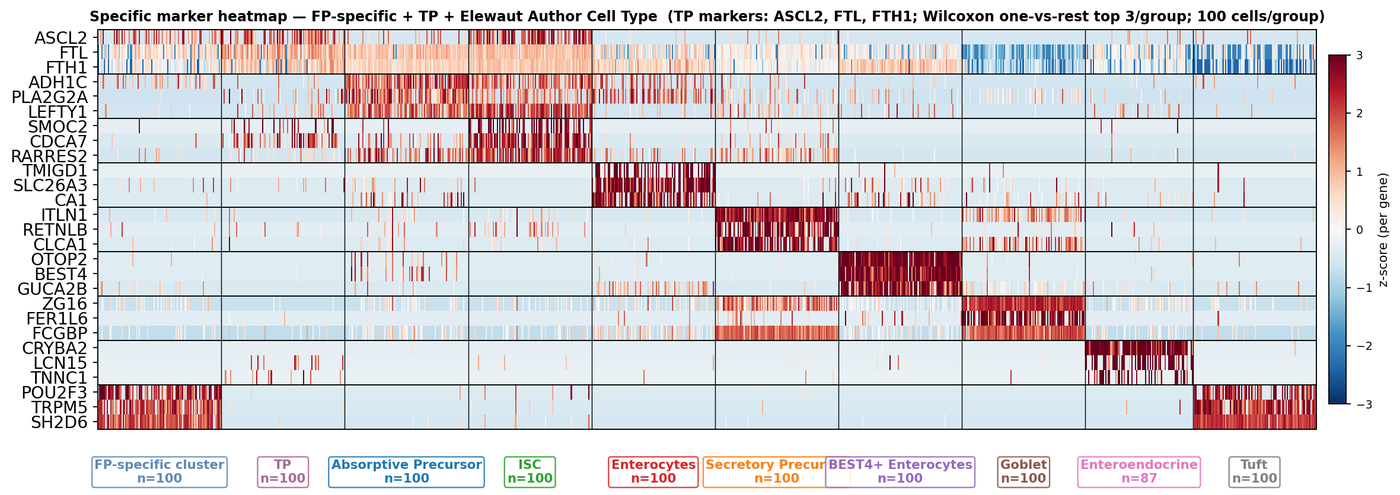

In [ ]:
# Fig 4a — marker heatmap (cell-type reference)
Image(str(COMP / "umap_FN_FP_clusters/marker_heatmap_FP_TP_vs_elewaut.png"))

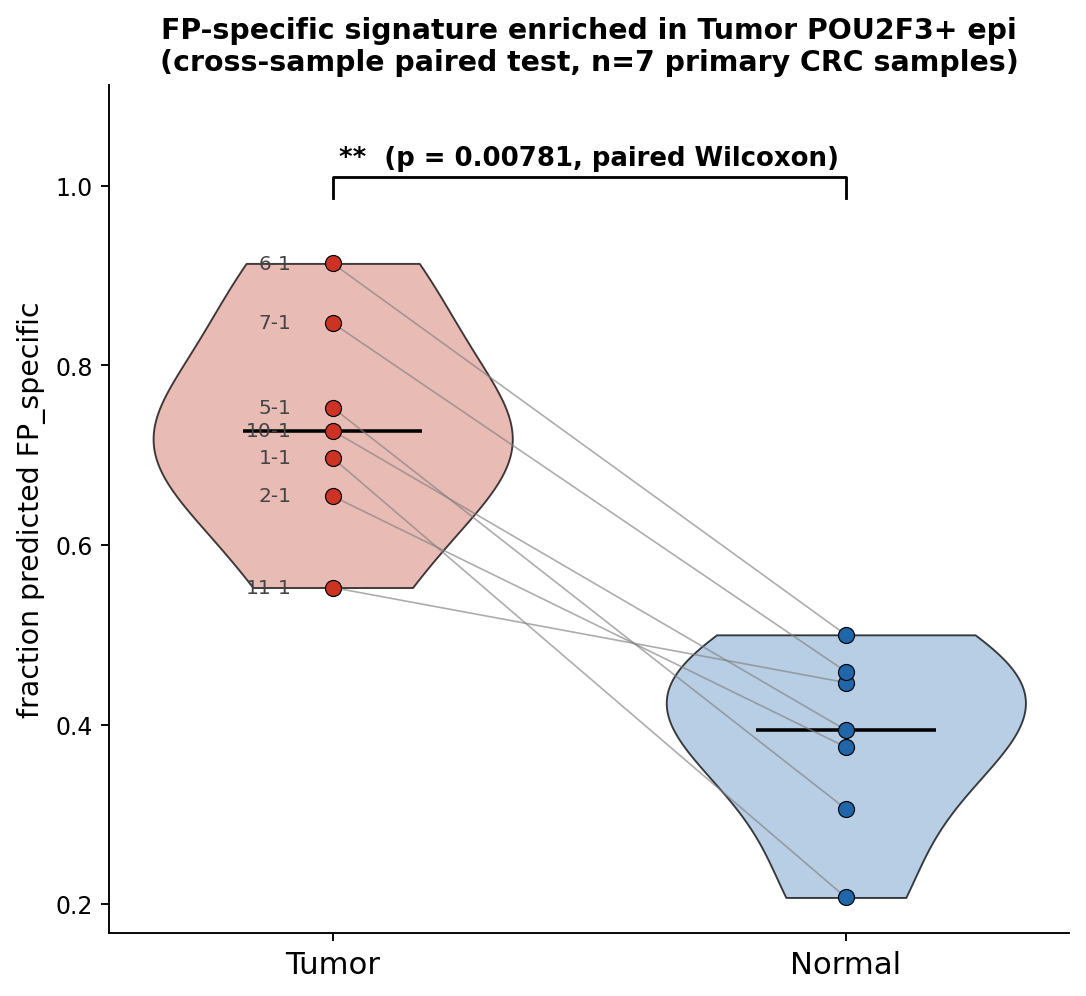

In [ ]:
# Fig 4b — %tuft-like: POU2F3+ cancer vs normal
Image(str(COMP / "umap_FN_FP_clusters/allsamples_POU2F3_ge1_paired_violin.png"))

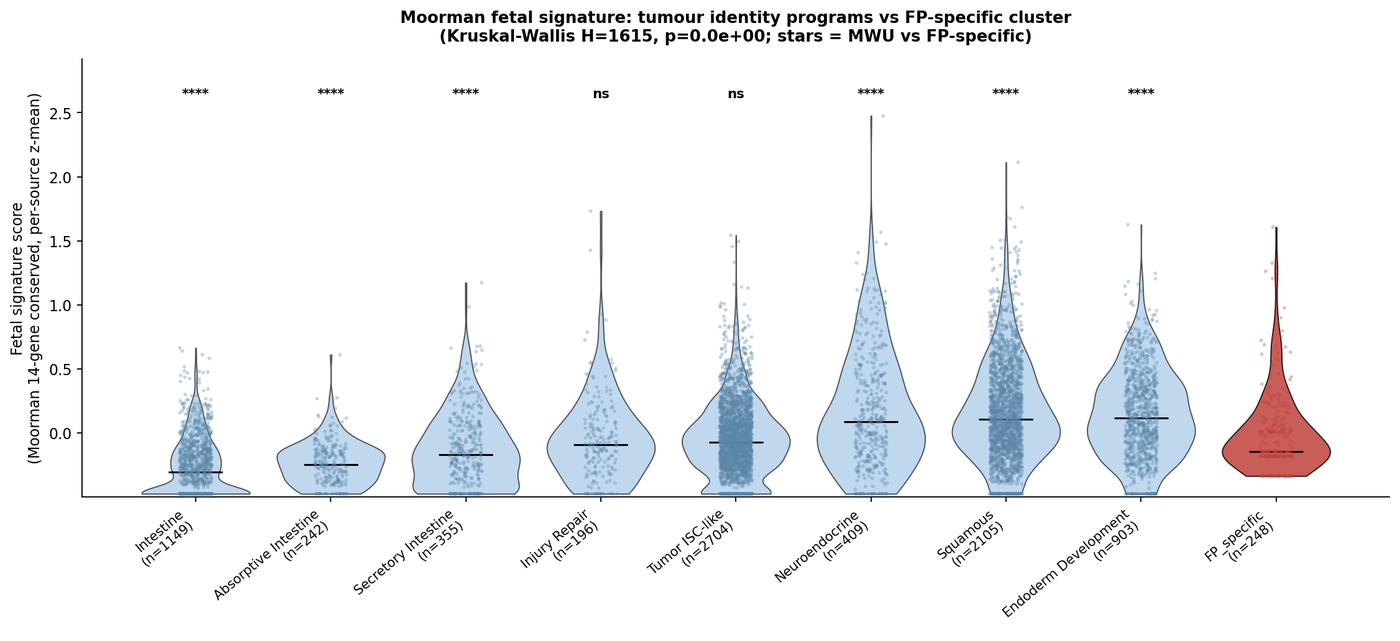

In [ ]:
# Fig 4e — Fetal signature (tumour identity programs)
Image(str(COMP / "umap_FN_FP_clusters/fetal_moorman_programs_vs_FPspec_violin.png"))

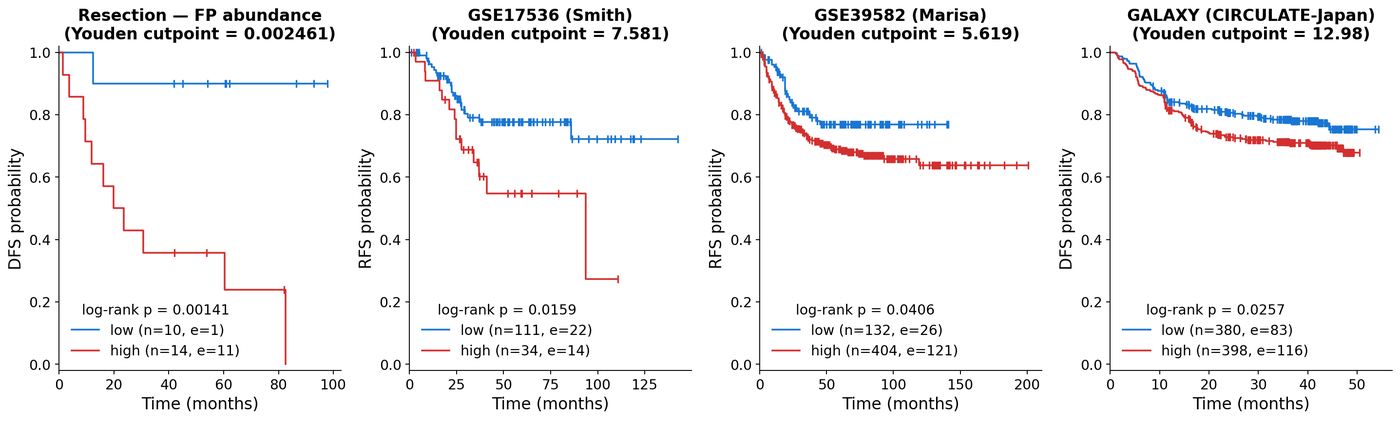

In [ ]:
# Fig 4f/4g — relapse Kaplan-Meier (4 cohorts)
Image(str(COMP / "umap_FN_FP_clusters/km_panel_resection_smith_marisa_galaxy.png"))